In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import os
import numpy as np
import pandas as pd
import torch
from torch import Tensor
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns
from datetime import datetime

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.ctmc import CTMCDataset
from peint.models.modules.ctmc_module import CTMCModule
from peint.models.nets.ctmc import NeuralCTMC, NeuralCTMCGenerator

from evo.tensor import collate_tensors
from evo.dataset import ComplexCherriesDataset, ComplexCherriesCollection
from evo.tokenization import Vocab

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Inference Experiments

In [34]:
# Load the cached results directory where we will save all intermediate and final results
paper_dir = Path("/scratch/users/stephen.lu/projects/protevo/paper")
date = "dms_eval"
# date = datetime.now().strftime("%Y-%m-%d")
results_dir = paper_dir / f"{date}"
os.makedirs(results_dir, exist_ok=True)

In [ ]:
# Load trained model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/logs/train/runs")

# Aligned TR Rosetta Checkpoint
# ckpt_path = ckpt_dir / "2025-12-12_03-54-53/checkpoints/last.ckpt"

IS_ANTIBODY = True
IS_AHO = False

# Antibody Jaffe Checkpoint - Ali
# ckpt_path = ckpt_dir / "2025-12-25_19-03-06/checkpoints/epoch_002.ckpt"

# Antibody DASM Checkpoint - Ali
ckpt_path = ckpt_dir / "2025-12-26_00-52-34/checkpoints/epoch_001.ckpt"

# Antibody Jaffe Checkpoint - AHO
# IS_AHO = True
# ckpt_path = ckpt_dir / "2025-12-15_04-09-58/checkpoints/epoch_007.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = CTMCModule.load_from_checkpoint(ckpt_path, map_location=device, strict=False)
module = module.eval()

net: NeuralCTMC = module.net
vocab: Vocab = net.vocab

special_tok_idxs = [
    vocab.bos_idx,
    vocab.pad_idx,
    vocab.eos_idx,
    vocab.unk_idx,
    vocab.mask_idx,
    vocab.tokens_to_idx.get("<null_1>", -1),
    vocab.tokens_to_idx.get(".", -1),
    vocab.tokens_to_idx.get("X", -1),
    vocab.tokens_to_idx.get("B", -1),
    vocab.tokens_to_idx.get("Z", -1),
    vocab.tokens_to_idx.get("O", -1),
    vocab.tokens_to_idx.get("U", -1),
]
special_tok_idxs = torch.tensor(special_tok_idxs, device=device)

Using device: cuda


In [315]:
def dataloader_from_dataset(dataset: torch.utils.data.Dataset, batch_size=32, *args, **kwargs):
    dataset = CTMCDataset(
        dataset=dataset,
        sep_token=".",
        vocab=vocab,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        *args,
        **kwargs,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, net: NeuralCTMC, n_batches = 100, ignore_gaps_in_y=False, use_stationary=False):
    lls, bls, ppl = [], [], []

    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        x, y, t, x_sizes = batch

        with (torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16)):
            Q, pi = net(x, x_sizes=x_sizes)  # (B, L, V, V)
            if use_stationary:
                # add a small epsilon to the stationary distribution to avoid log(0)
                log_probs: Tensor = torch.log(pi).clamp(min=-1e10)
            else:
                P: Tensor = net.exp_Qt(Q, t)
                log_probs: Tensor = net.log_Px(P, x)    # (B, L, V)

        nll = F.cross_entropy(
            log_probs.transpose(-1, -2),
            y,
            ignore_index=vocab.pad_idx,
            reduction="none",
        )
        aa_tok_mask = torch.isin(y, special_tok_idxs, invert=True)
        if ignore_gaps_in_y:
            gap_tok_mask = (y == vocab.tokens_to_idx.get("-", -1))
            aa_tok_mask = aa_tok_mask & ~gap_tok_mask

        ll = -nll * aa_tok_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())
        bls.append(t.detach().cpu().numpy())
        nll_mean = (nll * aa_tok_mask.float()).sum(dim=-1) / aa_tok_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks, skip_gap_tokens=False):
    tokens = []
    gap_idx = vocab.tokens_to_idx.get("-", -1)
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if skip_gap_tokens and tok == gap_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [ ]:
# load the antibody donor 4 dataset
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/aa/dx.txt")
datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/aho/d4.txt")
dataset = ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1)

# load the TR Rosetta test transitions dataset
# data_dir = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/tr_rosetta_15k_aligned/test_transitions")
# dataset = ComplexCherriesCollection(data_dir=data_dir, file_ext="txt", sep_token=".", min_t=0., chain_id_offset=1, max_len=1024)
# family_ids = dataset.family_ids

dataloader = dataloader_from_dataset(dataset=dataset, batch_size=32, num_workers=4)
print(f"Number of batches in dataloader: {len(dataloader)}")

# load the generator from the base network
generator = NeuralCTMCGenerator(neural_ctmc=net).to(device)
generator = generator.eval()

Number of batches in dataloader: 1888


### Performing Inference on the Test Dataset Transitions

In [ ]:
# run inference on the dataloader
n_batches = -1

lls, bls, ppl = [], [], []
all_hv_szs, all_lt_szs = [], []
all_hv_nlls, all_lt_nlls = [], []

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    
    x, y, t, x_sizes = batch

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        Q, pi = net(x, x_sizes=x_sizes)  # (B, L, V, V)
        log_probs: Tensor = module.forward(x, t, x_sizes=x_sizes, Q=Q)  # (B, L, V)

    if IS_ANTIBODY:
        # get heavy chain lengths
        hc_lens = (x_sizes[:,0] - 2).detach().cpu()
        lc_lens = (x_sizes[:,1] - 1).detach().cpu()

        # decode the true parent and child sequence using the vocab
        true_child_seqs = [decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))]
        true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, hc_lens)])

    # Keep unreduced to get per-site time likelihood (B, L)
    nll = F.cross_entropy(
        log_probs.transpose(-1, -2),
        y,
        ignore_index=vocab.pad_idx,
        reduction="none",
    ).detach().cpu().numpy()

    if IS_ANTIBODY:
        # separate nlls by heavy chain and light chain
        hv_nlls = [nll[i, :L] for i, L in enumerate(hc_lens)]
        lt_nlls = [nll[i, L+1:L+1+lc_lens[i]] for i, L in enumerate(hc_lens)]
        assert all([len(hvll) == len(hvc) for hvll, hvc in zip(hv_nlls, true_ch_hv_seqs)])
        assert all([len(ltll) == len(ltc) for ltll, ltc in zip(lt_nlls, true_ch_lt_seqs)])
    
        all_hv_nlls.extend(hv_nlls)
        all_lt_nlls.extend(lt_nlls)
        all_hv_szs.append(hc_lens.detach().cpu().numpy())
        all_lt_szs.append(lc_lens.detach().cpu().numpy())

    bls.append(t.detach().cpu().numpy())
    padding_mask = (y != vocab.pad_idx).detach().cpu().numpy()
    ll = -nll * padding_mask    # numpy array (B, L)
    ll_per_site = ll.sum(axis=-1) / padding_mask.sum(axis=-1)   # numpy array (B,)
    lls.append(ll_per_site)
    ppl.append(np.exp(-ll_per_site))

    n_batches -= 1
    if n_batches == 0:
        break

Inference: 100%|█████████████████████████████████████████████████████████████████████████| 1888/1888 [02:58<00:00, 10.59it/s]


In [ ]:
# pad the nlls to the same length
if IS_ANTIBODY:
    hv_nlls_padded = collate_tensors(all_hv_nlls, constant_value=0.0)
    lt_nlls_padded = collate_tensors(all_lt_nlls, constant_value=0.0)
    hv_szs = np.concatenate(all_hv_szs)
    lt_szs = np.concatenate(all_lt_szs)

bls = np.concatenate(bls)
lls = np.concatenate(lls)
ppl = np.concatenate(ppl)

if IS_ANTIBODY:
    print(hv_nlls_padded.shape, lt_nlls_padded.shape, hv_szs.shape, lt_szs.shape, bls.shape, lls.shape, ppl.shape)
else:
    print(bls.shape, lls.shape, ppl.shape)

(60403, 149) (60403, 148) (60403,) (60403,) (60403, 1) (60403,) (60403,)


In [97]:
# combine these numpy arrays into a numpy structured array and save to disk
save_path = "/accounts/projects/yss/stephen.lu/peint/results/inf_eval"
np.savez(f"{save_path}/ctmc_nlls_d4.npz", hv_nlls=hv_nlls_padded, lt_nlls=lt_nlls_padded, hv_szs=hv_szs, lt_szs=lt_szs, bls=bls)

In [11]:
print('test perplexity: ', np.mean(ppl))

# save branch, lls, and ppls to a dataframe
# df = pd.DataFrame({
#     "branch": bls[:,0],
#     "log_likelihood": lls,
#     "perplexity": ppl,
# })

# df.to_csv("ctmc_model_d4.csv", index=False)

test perplexity:  2.347193450503017


In [ ]:
from matplotlib.ticker import ScalarFormatter

# scatter plot the likelihood per site against branch lengths
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df['likelihood'] = df['ll'].progress_apply(lambda x: np.exp(x))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df.branch_length, df.likelihood, alpha=0.1, label="Log-likelihood per sample", s=5)

# fit a line plot to the mean likelihood per site against branch lengths
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(0.15)
binned_df = df.groupby("bl_bin").mean()
# ax.plot(binned_df['branch_length'], binned_df['likelihood'], color='red', label='Mean likelihood per bin', linewidth=2)

# set max x-axis to 5
ax.set_xlim(0, 5)

# ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)
ax.xaxis.get_major_formatter().set_useOffset(False)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Likelihood per site")
ax.set_title("Likelihood per site vs Branch Length")
ax.legend()
plt.show()

## Sampling Experiments
### Unconditional Sampling from the parent sequences in the test dataset

In [ ]:
# first we try generating child sequences using the one-shot independent site method
real_parent_seqs, real_child_seqs = [], []
ind_sim_child_seqs, dep_sim_child_seqs = [], []
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
ind_sim_child_hv_seqs, ind_sim_child_lt_seqs = [], []
dep_sim_child_hv_seqs, dep_sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 10

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes = batch
    
    # decode the true parent and child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x[i].cpu().numpy()) for i in range(x.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))]

    if IS_ANTIBODY:
        # get heavy chain lengths
        hc_lens = x_sizes[:,0] - 2
        true_pr_hv_seqs, true_pr_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_parent_seqs, hc_lens)])
        true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, hc_lens)])

    # sample a child sequence using the model
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        y_ind_decoded = generator.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)
        y_dep_decoded = generator.generate_with_fake_gillespie(t=t, x=x, x_sizes=x_sizes)

    sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
    sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]

    if IS_ANTIBODY:
        sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_ind_child_seqs, hc_lens)])
        assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_ind_child_seqs)])
        sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_dep_child_seqs, hc_lens)])
        assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_dep_child_seqs)])
    
    if IS_ANTIBODY:
        real_parent_hv_seqs.extend(true_pr_hv_seqs)
        real_parent_lt_seqs.extend(true_pr_lt_seqs)
        real_child_hv_seqs.extend(true_ch_hv_seqs)
        real_child_lt_seqs.extend(true_ch_lt_seqs)
        ind_sim_child_hv_seqs.extend(sim_ind_hv_seqs)
        ind_sim_child_lt_seqs.extend(sim_ind_lt_seqs)
        dep_sim_child_hv_seqs.extend(sim_dep_hv_seqs)
        dep_sim_child_lt_seqs.extend(sim_dep_lt_seqs)
        
    real_parent_seqs.extend(true_parent_seqs)
    real_child_seqs.extend(true_child_seqs)
    ind_sim_child_seqs.extend(sim_ind_child_seqs)
    dep_sim_child_seqs.extend(sim_dep_child_seqs)
    branch_lengths.extend(t.squeeze().detach().cpu().numpy().tolist())

    n_batches -= 1
    if n_batches == 0:
        break

In [83]:
print(real_parent_seqs[0])
print(real_child_seqs[0])
print(ind_sim_child_seqs[0])
print(dep_sim_child_seqs[0])

GVCACPRIYMPVCGSNLKTYNNDCLLRCEINSDLGRANNLRKIADQACDNLTDNVND
GMCACPRIYMPVCGSDLKTYSNRCELNCSVDSPRGRASNLRLLREGSCEDKQEIVEM
SQCACPRNYNPVCGTSLQTYDNHCFMHCESCS-RGQ--DLRKVKDGECENLTNVVY-
--CACPHIYMPVCGSNQKTYNNQCLMRCHICIGSGCTGSLEKVEEGECN--------


In [ ]:
# calculate hamming distances between corresponding real and simulated sequences
hv_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, dep_sim_child_hv_seqs)]
lt_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, dep_sim_child_lt_seqs)]
_len = len(hv_ind_aa_hamming_dists)

data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_ind_aa_hamming_dists + hv_dep_aa_hamming_dists + lt_ind_aa_hamming_dists + lt_dep_aa_hamming_dists,
    "chain": ["heavy"] * 2 * _len + ["light"] * 2 * _len,
    "method": ["matrix exponential"] * _len + ["gillespie"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

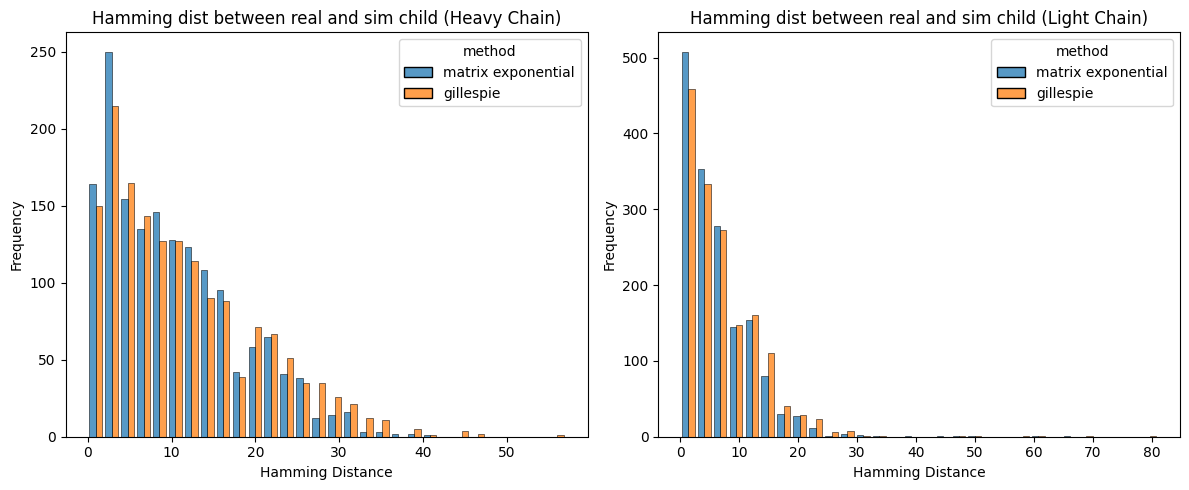

In [18]:
# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side) colored by method
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data_df[data_df["chain"] == "heavy"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[0], legend=True)
sns.histplot(data=data_df[data_df["chain"] == "light"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[1], legend=True)

# add labels and legend please
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency')
ax[1].set_title('Hamming dist between real and sim child (Light Chain)')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')
# ax[0].legend(title='Method')
# ax[1].legend(title='Method')

plt.tight_layout()
plt.show()

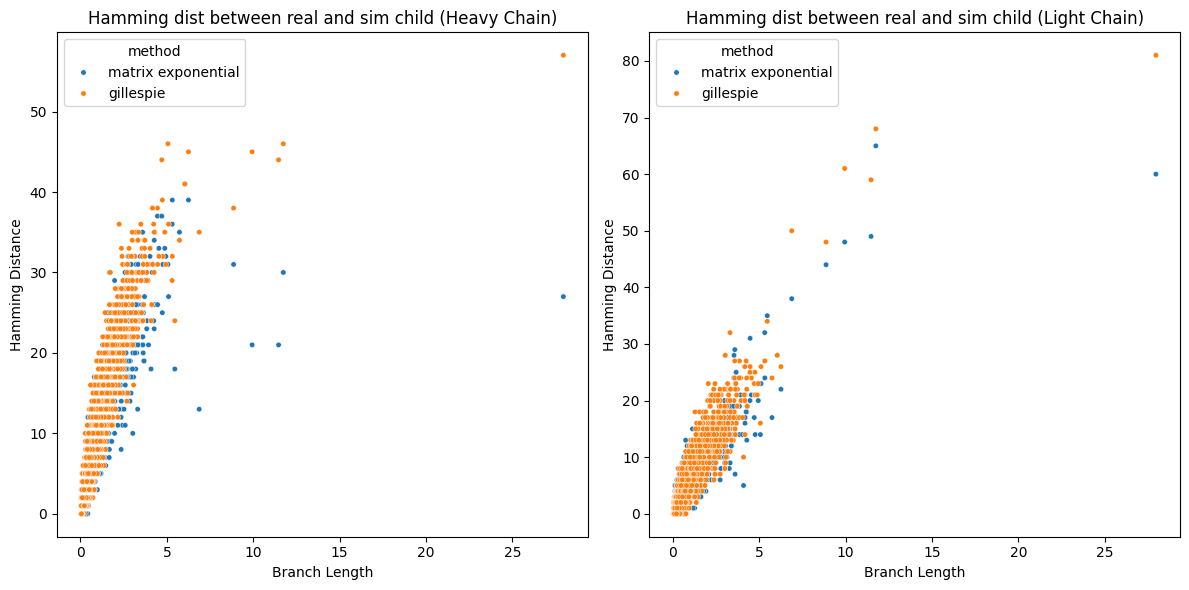

In [19]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=data_df[data_df["chain"] == "heavy"], x="bl", y="dist", hue="method", ax=ax[0], legend=True, s=15)
sns.scatterplot(data=data_df[data_df["chain"] == "light"], x="bl", y="dist", hue="method", ax=ax[1], legend=True, s=15)

# add titles and labels
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_title("Hamming dist between real and sim child (Light Chain)")
ax[1].set_xlabel("Branch Length")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [20]:
# calculate hamming distance between real parent and all child sequences, real and fake

hv_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, real_child_hv_seqs)]
hv_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, dep_sim_child_hv_seqs)]

lt_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, real_child_lt_seqs)]
lt_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, dep_sim_child_lt_seqs)]

_len = len(hv_real_hd)

hv_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_real_hd + hv_ind_hd + hv_dep_hd, 
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})
lt_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": lt_real_hd + lt_ind_hd + lt_dep_hd,
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

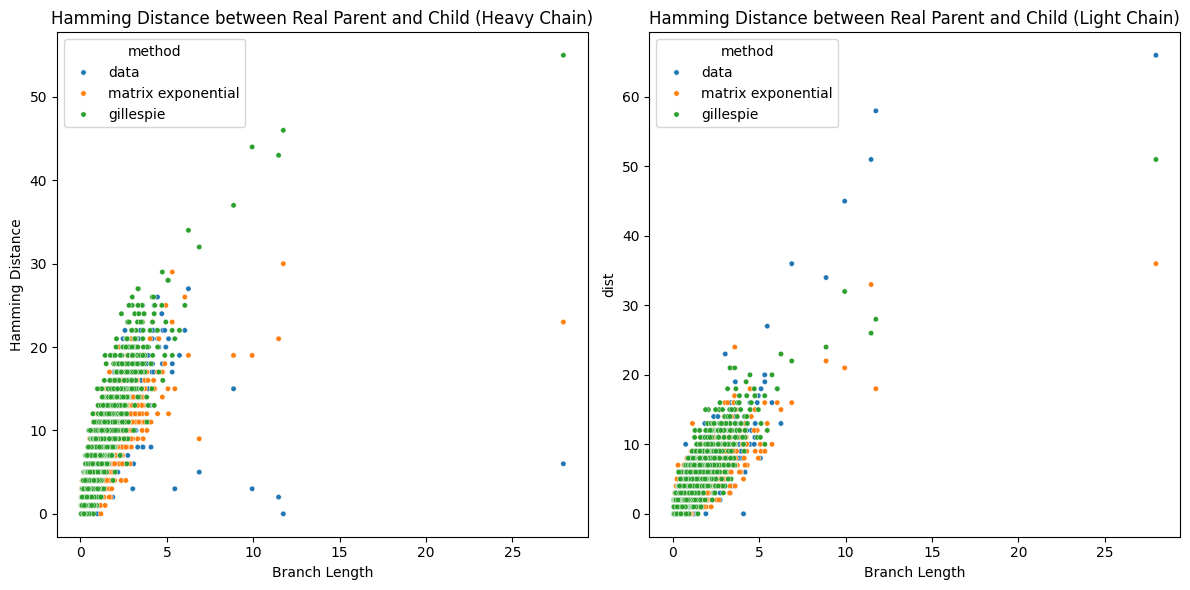

In [21]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=hv_data_df, x="bl", y="dist", hue="method", ax=ax[0], legend="full", s=15)
sns.scatterplot(data=lt_data_df, x="bl", y="dist", hue="method", ax=ax[1], legend="full", s=15)

ax[0].set_title("Hamming Distance between Real Parent and Child (Heavy Chain)")
ax[1].set_title("Hamming Distance between Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

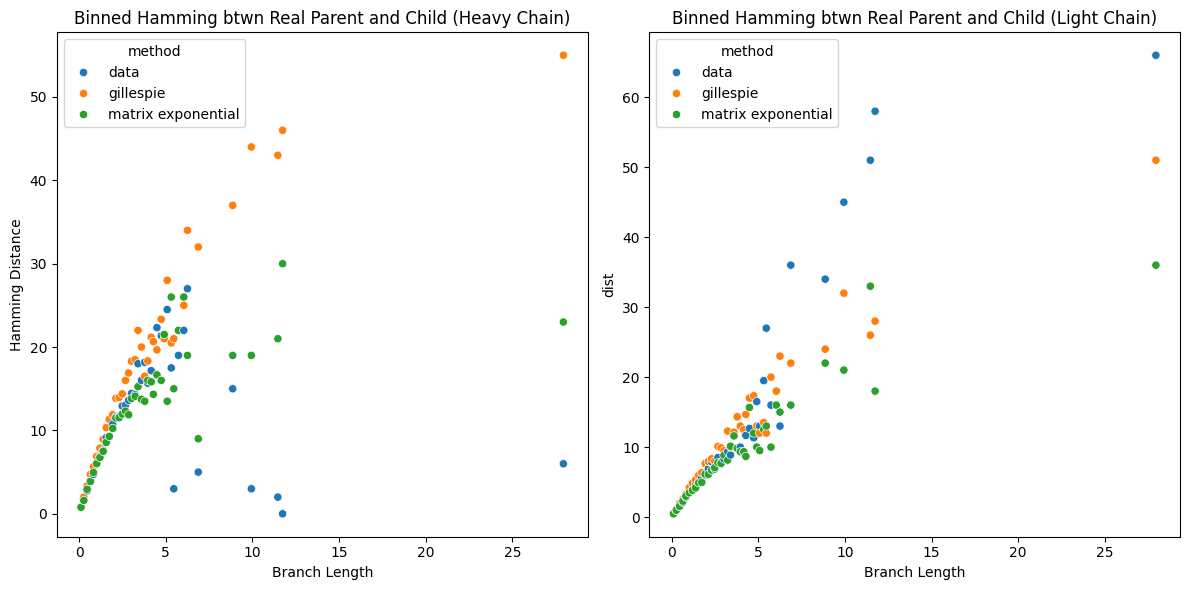

In [22]:
# do this plot again, but now bin by branch length
hv_quantile, lt_quantile = hv_data_df.bl.quantile(0.15), lt_data_df.bl.quantile(0.15)
hv_data_df["bl_bin"] = hv_data_df.bl // hv_quantile.astype(float)
lt_data_df["bl_bin"] = lt_data_df.bl // lt_quantile.astype(float)

binned_hv_u = hv_data_df.groupby(by=["bl_bin", "method"]).mean()
binned_lt_u = lt_data_df.groupby(by=["bl_bin", "method"]).mean()
binned_hv_s = hv_data_df.groupby(by=["bl_bin", "method"]).std()
binned_lt_s = lt_data_df.groupby(by=["bl_bin", "method"]).std()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=binned_hv_u, x="bl", y="dist", hue="method", ax=ax[0], legend="full")
sns.scatterplot(data=binned_lt_u, x="bl", y="dist", hue="method", ax=ax[1], legend="full")

# Add confidence intervals
# ax[0].fill_between(
#     binned_hv_u.bl,
#     binned_hv_u.dist - binned_hv_s.dist,
#     binned_hv_u.dist + binned_hv_s.dist,
#     alpha=0.2,
# )
# ax[1].fill_between(
#     binned_lt_u.bl,
#     binned_lt_u.dist - binned_lt_s.dist,
#     binned_lt_u.dist + binned_lt_s.dist,
#     alpha=0.2,
# )

ax[0].set_title("Binned Hamming btwn Real Parent and Child (Heavy Chain)")
ax[1].set_title("Binned Hamming btwn Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [24]:
# save sampled sequences to disk, use different file for dep and ind methods
# format should be csv with real parent, real child, simulated child, and branch length

# Create DataFrames for independent and dependent methods
ind_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": ind_sim_child_hv_seqs,
    "sim_child_lt": ind_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

dep_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": dep_sim_child_hv_seqs,
    "sim_child_lt": dep_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

# Save to CSV files
ind_df.to_csv("results/gen_eval/ctmc_mat_exp.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie.csv", index=False)

### Sampling from same parent with different branch lengths

In [ ]:
# first we try generating child sequences using the one-shot independent site method
batch = next(iter(dataloader))
batch = [b.to(device) for b in batch]
x, y, t, x_sizes = batch

hv_sz = x_sizes[0, 0] - 2

real_parent_seq = decode_sequence_from_toks(x[0].cpu().numpy())
real_child_seq = decode_sequence_from_toks(y[0].cpu().numpy())
real_pr_hv_seq = real_parent_seq[:hv_sz]
real_pr_lt_seq = real_parent_seq[hv_sz+1:]
real_ch_hv_seq = real_child_seq[:hv_sz]
real_ch_lt_seq = real_child_seq[hv_sz+1:]

branch_lengths = torch.from_numpy(np.linspace(0, 50, 100))
x = x[0].repeat(len(branch_lengths), 1).cuda()
x_sizes = x_sizes[0].repeat(len(branch_lengths), 1).cuda()
ts = branch_lengths.reshape(-1, 1).cuda()

with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    y_ind_decoded = generator.generate_with_independent_sites(t=ts, x=x, x_sizes=x_sizes)
    y_dep_decoded = generator.generate_with_fake_gillespie(t=ts, x=x, x_sizes=x_sizes, max_decode_steps=2048)

sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hv_sz], seq[hv_sz+1:]) for seq in sim_ind_child_seqs])

sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]
sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hv_sz], seq[hv_sz+1:]) for seq in sim_dep_child_seqs])

 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                          | 880/1024 [01:52<00:18,  7.84it/s]


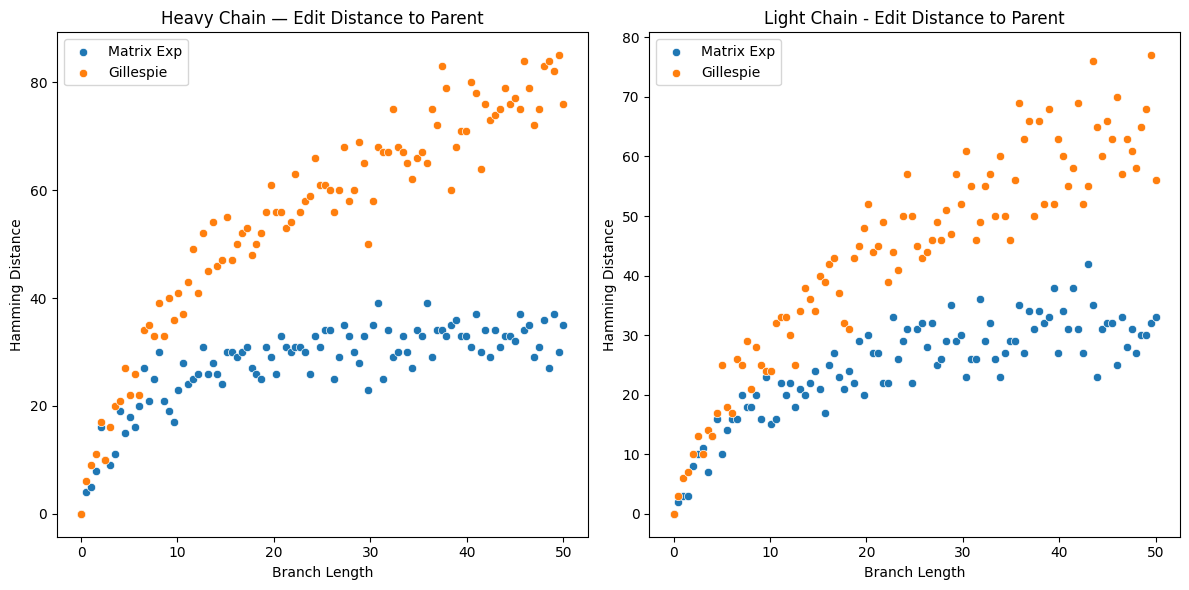

In [19]:
# calculate hamming distance between each of the simulated sequences and the real parent sequence
hv_hmd_ind = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_ind_hv_seqs]
hv_hmd_dep = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_dep_hv_seqs]
lt_hmd_ind = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_ind_lt_seqs]
lt_hmd_dep = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_dep_lt_seqs]

# plot hmd against branch lengths, color by method
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=branch_lengths, y=hv_hmd_ind, ax=ax[0], label="Matrix Exp")
sns.scatterplot(x=branch_lengths, y=hv_hmd_dep, ax=ax[0], label="Gillespie")
sns.scatterplot(x=branch_lengths, y=lt_hmd_ind, ax=ax[1], label="Matrix Exp")
sns.scatterplot(x=branch_lengths, y=lt_hmd_dep, ax=ax[1], label="Gillespie")

ax[0].set_title("Heavy Chain — Edit Distance to Parent")
ax[1].set_title("Light Chain - Edit Distance to Parent")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()


In [21]:
# save the sampled sequences to disk

ind_data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_ind_hv_seqs,
    "lt_seqs": sim_ind_lt_seqs,
    "hv_hmd": hv_hmd_ind,
    "lt_hmd": lt_hmd_ind,
}
dep_data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_dep_hv_seqs,
    "lt_seqs": sim_dep_lt_seqs,
    "hv_hmd": hv_hmd_dep,
    "lt_hmd": lt_hmd_dep,
}

# save to csv files
ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

ind_df.to_csv("results/gen_eval/ctmc_mat_exp_vary_t.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie_vary_t.csv", index=False)

### Generate multihop trajectories down a tree

In [6]:
import random
from Bio.Seq import Seq
from evo.phylogeny import df_to_ete3_tree
from peint.models.frameworks.peint import simulate_evolution_with_rejection_sampling

In [7]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/raw")

heavy = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igh_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
kappa = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igk_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
lambd = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igl_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)

heavy['family'] = heavy['sample_id'] + '_' + heavy['family'].astype(str)
kappa['family'] = kappa['sample_id'] + '_' + kappa['family'].astype(str)
lambd['family'] = lambd['sample_id'] + '_' + lambd['family'].astype(str)

heavy['edge_id'] = heavy['family'] + ';' + heavy['parent_name'] + ';' + heavy['child_name']
kappa['edge_id'] = kappa['family'] + ';' + kappa['parent_name'] + ';' + kappa['child_name']
lambd['edge_id'] = lambd['family'] + ';' + lambd['parent_name'] + ';' + lambd['child_name']

In [8]:
keep_kappa = (kappa.edge_id.isin(heavy.edge_id)) & ~(kappa.edge_id.isin(lambd.edge_id))
keep_lambd = (lambd.edge_id.isin(heavy.edge_id)) & ~(lambd.edge_id.isin(kappa.edge_id))
kappa = kappa[keep_kappa]
lambd = lambd[keep_lambd]
keep_heavy = (heavy.edge_id.isin(kappa.edge_id)) | (heavy.edge_id.isin(lambd.edge_id))
heavy = heavy[keep_heavy]

In [9]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
keep_cols = ['parent', 'child', 'branch_length', 'depth', 'distance', 'v_gene', 'cdr1_codon_start', 
             'cdr1_codon_end', 'cdr2_codon_start', 'cdr2_codon_end', 'cdr3_codon_start', 'cdr3_codon_end',
             'parent_is_naive', 'child_is_leaf']
keep_cols = merge_cols + keep_cols

In [10]:
heavy_kappa = pd.merge(heavy[keep_cols], kappa[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(heavy[keep_cols], lambd[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)

In [11]:
family = 'd4_203694-igk-203694'
edges = full_df[full_df.family == family]

edges = edges.rename(columns={'branch_length_heavy':'branch_length'})
edges['branch_length'] /= edges['branch_length'].mean()

tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])
print(tree.get_ascii())


                                                                                            /-AAACGGGTCATTCACT-1-1279069_contig_h
                                                                                      /Node16
                                                                                /Node15     \-CAGATCAAGGACACCA-1-1287171_contig_h
                                                                               |     |
                                                                          /Node14     \-GCCTCTAAGACTGGGT-1-1287174_contig_h
                                                                         |     |
                                                                         |     |      /-CGGACTGGTGAGGCTA-1-1287171_contig_h
                                                                    /Node13     \Node17
                                                                   |     |            \-CTCGTCAAGTACGTTC-1-1279070_contig_h
                 

In [12]:
# translate amino acid sequences from nucleotide sequences
edges['parent_heavy_aa'] = edges['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
edges['parent_light_aa'] = edges['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
edges['child_heavy_aa'] = edges['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
edges['child_light_aa'] = edges['child_light'].progress_apply(lambda x: str(Seq(x).translate()))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:00<00:00, 25986.68it/s]


In [13]:
# extract root and leaves from the tree
root_data = edges[edges.parent_name == "naive"].iloc[0][["parent_heavy_aa", "parent_light_aa"]]
root_seq = root_data.parent_heavy_aa + "." + root_data.parent_light_aa

leaf_data = edges[edges.child_name.str.contains("contig")][["child_name", "child_heavy_aa", "child_light_aa"]]
leaf_data["child_seq"] = leaf_data.child_heavy_aa + "." + leaf_data.child_light_aa

# calculate x_sizes from the root sequence since we want to have same length samples
xs = root_seq.split(".")
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

print("Root Sequence: ")
print(root_seq)
print(len(root_seq))

Root Sequence: 
EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLEWVSYISSSGSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCASGGYCTNGVCYTAEYFQHWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQYNSYPWTFGQGTKVEIK
234


In [ ]:
# prepare tree sampling from root

def gillespie_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return generator.generate_with_fake_gillespie(t=t, x=x, x_sizes=x_sizes, max_decode_steps=2048)

def matexp_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return generator.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)

def length_criterion(x):
    if x != len(root_seq):
        print(x)
        raise ValueError("Sequence length does not match root sequence length")
    return True

simulation_args = {
    "root_sequence": root_seq,
    "x_sizes": x_sizes, # use for fixed size
    "vocab": vocab,
    "tree": tree,
    "device": device,
    "max_decode_steps": 1024,
    "max_batch_size": 128,
    "n_sequences": 1,
    "p_threshold": 1.0,
    "length_criterion": length_criterion,
    "likelihood_fn": None,
    "max_retries": 3,
    "seed": 42,
}
gillespie_sim_args = simulation_args.copy()
gillespie_sim_args["generate_fn"] = gillespie_generate_fn
matexp_sim_args = simulation_args.copy()
matexp_sim_args["generate_fn"] = matexp_generate_fn

In [16]:
# sample down test tree and compare with real children
gillespie_samples = simulate_evolution_with_rejection_sampling(**gillespie_sim_args)
mat_exp_samples = simulate_evolution_with_rejection_sampling(**matexp_sim_args)

Simulated 0 / 146 nodes


  1%|█▋                                                                                                                                                                                                                             | 16/2048 [00:04<09:58,  3.39it/s]


Simulated 1 / 146 nodes


  0%|▏                                                                                                                                                                                                                               | 2/2048 [00:00<02:43, 12.50it/s]


Simulated 3 / 146 nodes


...

Simulated 283 / 146 nodes


  0%|                                                                                                                                                                                                                                        | 0/2048 [00:00<?, ?it/s]


Simulated 287 / 146 nodes


  0%|▉                                                                                                                                                                                                                               | 8/2048 [00:00<01:59, 17.07it/s]


Simulated 0 / 146 nodes
Simulated 1 / 146 nodes
Simulated 3 / 146 nodes
Simulated 7 / 146 nodes
Simulated 13 / 146 nodes
Simulated 23 / 146 nodes
Simulated 37 / 146 nodes
Simulated 57 / 146 nodes
Simulated 77 / 146 nodes
Simulated 103 / 146 nodes
Simulated 129 / 146 nodes
Simulated 159 / 146 nodes
Simulated 197 / 146 nodes
Simulated 227 / 146 nodes
Simulated 247 / 146 nodes
Simulated 261 / 146 nodes
Simulated 271 / 146 nodes
Simulated 277 / 146 nodes
Simulated 279 / 146 nodes
Simulated 281 / 146 nodes
Simulated 283 / 146 nodes
Simulated 287 / 146 nodes


In [18]:
# print number of leaves on the tree
print(f"Number of leaves in the tree: {len(leaf_data)}")

Number of leaves in the tree: 146


In [19]:
# Collect distances between random pairs of nodes
leaves = tree.get_leaves()
leaf_pairs = [(leaves[i], leaves[j]) for i in range(len(leaves)) for j in range(i+1, len(leaves))]
n_trajectories = len(leaf_pairs)
distances = []
gillespie_pairs = []
mat_exp_pairs = []
real_pairs = []

for node1, node2 in tqdm(leaf_pairs):
    node1_name, node2_name = node1.name, node2.name

    # Get the actual tree nodes
    node1 = tree.search_nodes(name=node1_name)[0]
    node2 = tree.search_nodes(name=node2_name)[0]
    
    # Calculate the distance between the two nodes
    total_dist = node1.get_distance(node2)
    
    # Collect the sequences at these two nodes for gillespie, mat_exp, and the real tree
    gillespie_pairs.append((gillespie_samples[node1_name], gillespie_samples[node2_name]))
    mat_exp_pairs.append((mat_exp_samples[node1_name], mat_exp_samples[node2_name]))
    
    real_seq_1 = leaf_data[leaf_data["child_name"]==node1_name]["child_seq"].values[0]
    real_seq_2 = leaf_data[leaf_data["child_name"]==node2_name]["child_seq"].values[0]
    real_pairs.append((real_seq_1, real_seq_2))
    
    distances.append({
        'node1': node1_name,
        'node2': node2_name,
        'distance': total_dist,
    })
    
    n_trajectories -= 1
    if n_trajectories == 0:
        break

distances_df = pd.DataFrame(distances)
print(f"Collected {len(distances)} pairwise distances")
print(f"\nDistance statistics:")
print(distances_df['distance'].describe())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 10584/10585 [00:08<00:00, 1319.61it/s]

Collected 10585 pairwise distances

Distance statistics:
count    10585.000000
mean         7.983843
std          1.911142
min          0.000090
25%          6.857767
50%          8.260338
75%          9.306199
max         14.098740
Name: distance, dtype: float64


In [20]:
gillespie_hv_hmd, gillespie_lt_hmd = [], []
mat_exp_hv_hmd, mat_exp_lt_hmd = [], []
real_hv_hmd, real_lt_hmd = [], []

for (seq1, seq2), (seq3, seq4), (seq5, seq6) in tqdm(zip(gillespie_pairs, mat_exp_pairs, real_pairs)):
    # Gillespie samples
    gill_n1_hv, gill_n1_lt = seq1.split(".")
    gill_n2_hv, gill_n2_lt = seq2.split(".")
    gillespie_hv_hmd.append(compute_hamming_distance(gill_n1_hv, gill_n2_hv))
    gillespie_lt_hmd.append(compute_hamming_distance(gill_n1_lt, gill_n2_lt))
    
    # Matrix exponential samples
    mat_n1_hv, mat_n1_lt = seq3.split(".")
    mat_n2_hv, mat_n2_lt = seq4.split(".")
    mat_exp_hv_hmd.append(compute_hamming_distance(mat_n1_hv, mat_n2_hv))
    mat_exp_lt_hmd.append(compute_hamming_distance(mat_n1_lt, mat_n2_lt))
    
    # Real sequences
    real_n1_hv, real_n1_lt = seq5.split(".")
    real_n2_hv, real_n2_lt = seq6.split(".")
    real_hv_hmd.append(compute_hamming_distance(real_n1_hv, real_n2_hv))
    real_lt_hmd.append(compute_hamming_distance(real_n1_lt, real_n2_lt))

# Add hamming distances to the dataframe
distances_df['gillespie_hv_hmd'] = gillespie_hv_hmd
distances_df['gillespie_lt_hmd'] = gillespie_lt_hmd
distances_df['mat_exp_hv_hmd'] = mat_exp_hv_hmd
distances_df['mat_exp_lt_hmd'] = mat_exp_lt_hmd
distances_df['real_hv_hmd'] = real_hv_hmd
distances_df['real_lt_hmd'] = real_lt_hmd

print("\nHamming distance statistics (Heavy Chain):")
print(distances_df[['gillespie_hv_hmd', 'mat_exp_hv_hmd', 'real_hv_hmd']].describe())
print("\nHamming distance statistics (Light Chain):")
print(distances_df[['gillespie_lt_hmd', 'mat_exp_lt_hmd', 'real_lt_hmd']].describe())

10585it [00:00, 20339.39it/s]


Hamming distance statistics (Heavy Chain):
       gillespie_hv_hmd  mat_exp_hv_hmd   real_hv_hmd
count      10585.000000    10585.000000  10585.000000
mean          32.631932       28.497496     28.161549
std            6.559484        7.235094      5.387408
min            0.000000        0.000000      0.000000
25%           29.000000       24.000000     25.000000
50%           33.000000       29.000000     28.000000
75%           37.000000       34.000000     32.000000
max           56.000000       49.000000     49.000000

Hamming distance statistics (Light Chain):
       gillespie_lt_hmd  mat_exp_lt_hmd   real_lt_hmd
count      10585.000000    10585.000000  10585.000000
mean          21.713368       18.273595     15.447803
std            5.043728        4.524913      3.937885
min            0.000000        0.000000      0.000000
25%           18.000000       16.000000     13.000000
50%           22.000000       19.000000     16.000000
75%           25.000000       21.000000     18.0

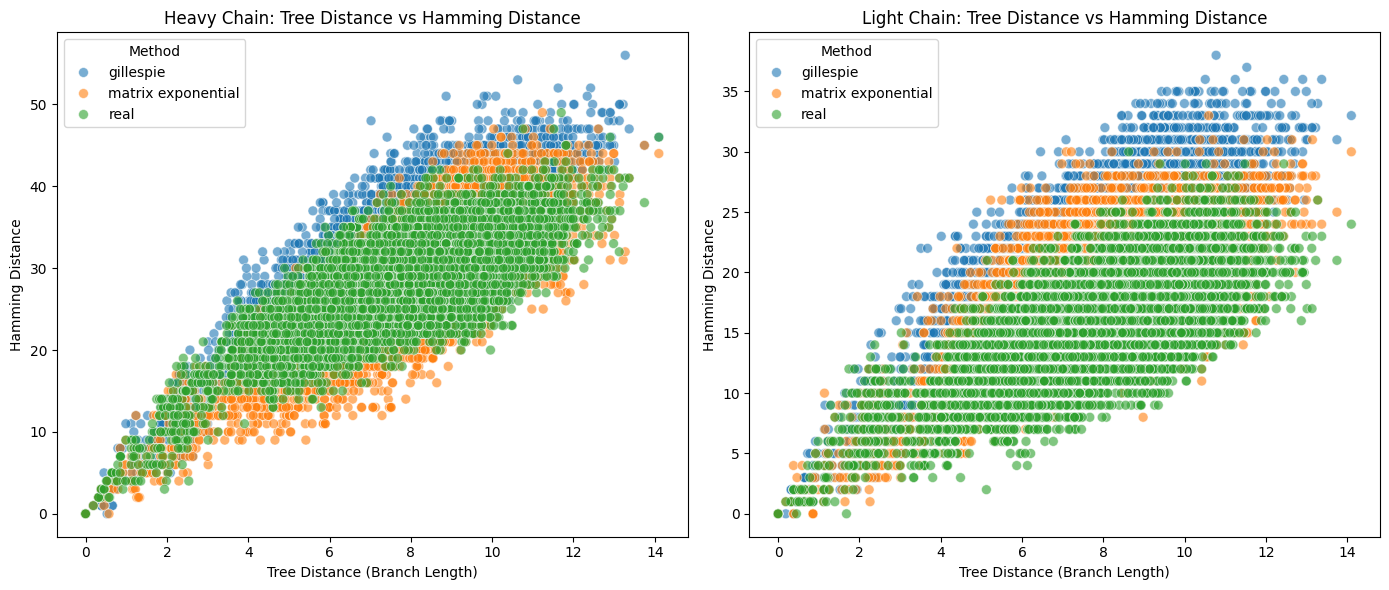

In [26]:
# plot distance versus hamming distance for each chain, colored by method

# Reshape data for plotting
_n = len(distances_df)
plot_df = pd.DataFrame({
    'distance': distances_df['distance'].tolist() * 3 + distances_df['distance'].tolist() * 3,
    'hamming_dist': (
        distances_df['gillespie_hv_hmd'].tolist() + 
        distances_df['mat_exp_hv_hmd'].tolist() + 
        distances_df['real_hv_hmd'].tolist() +
        distances_df['gillespie_lt_hmd'].tolist() + 
        distances_df['mat_exp_lt_hmd'].tolist() + 
        distances_df['real_lt_hmd'].tolist()
    ),
    'method': ['gillespie'] * _n + ['matrix exponential'] * _n + ['real'] * _n + 
              ['gillespie'] * _n + ['matrix exponential'] * _n + ['real'] * _n,
    'chain': ['heavy'] * (3 * _n) + ['light'] * (3 * _n)
})

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Heavy chain
sns.scatterplot(
    data=plot_df[plot_df['chain'] == 'heavy'], 
    x='distance', 
    y='hamming_dist', 
    hue='method', 
    ax=ax[0], 
    alpha=0.6,
    s=50
)
ax[0].set_title('Heavy Chain: Tree Distance vs Hamming Distance')
ax[0].set_xlabel('Tree Distance (Branch Length)')
ax[0].set_ylabel('Hamming Distance')
ax[0].legend(title='Method')

# Light chain
sns.scatterplot(
    data=plot_df[plot_df['chain'] == 'light'], 
    x='distance', 
    y='hamming_dist', 
    hue='method', 
    ax=ax[1], 
    alpha=0.6,
    s=50
)
ax[1].set_title('Light Chain: Tree Distance vs Hamming Distance')
ax[1].set_xlabel('Tree Distance (Branch Length)')
ax[1].set_ylabel('Hamming Distance')
ax[1].legend(title='Method')

plt.tight_layout()
plt.show()

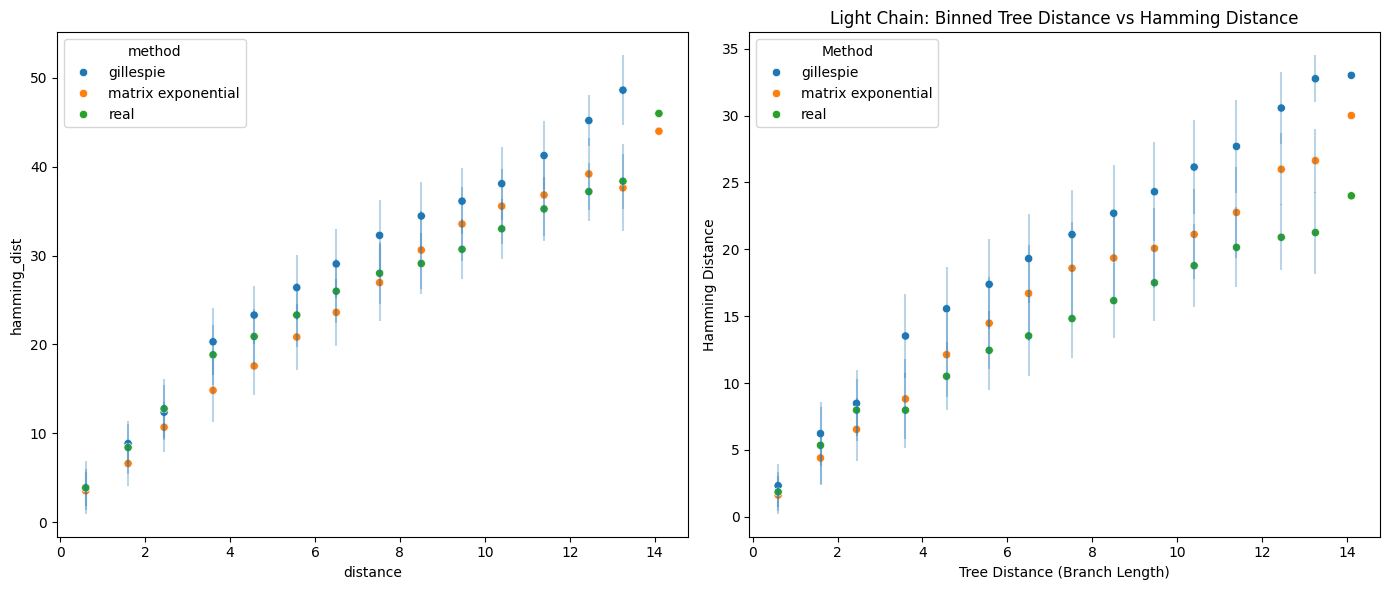

In [46]:
# make the same plot as above, but now binned by the branch length distance so that it is easier to see trends
# plot_df['distance_bin'] = plot_df['distance'] // plot_df['distance'].quantile(0.15).astype(float)
plot_df['distance_bin'] = plot_df['distance'] // 1.0  # bin size of 1.0
binned_mean = plot_df.groupby(['chain', 'method', 'distance_bin']).mean().reset_index()
binned_std = plot_df.groupby(['chain', 'method', 'distance_bin']).std().reset_index()
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Heavy chain
sns.scatterplot(
    data=binned_mean[binned_mean['chain'] == 'heavy'], 
    x='distance', 
    y='hamming_dist', 
    hue='method', 
    ax=ax[0]
)

# Light chain
sns.scatterplot(
    data=binned_mean[binned_mean['chain'] == 'light'], 
    x='distance', 
    y='hamming_dist', 
    hue='method', 
    ax=ax[1]
)

# add error bars representing one standard deviation
for method in binned_mean['method'].unique():
    heavy_data = binned_mean[(binned_mean['chain'] == 'heavy') & (binned_mean['method'] == method)]
    heavy_std = binned_std[(binned_std['chain'] == 'heavy') & (binned_std['method'] == method)]
    ax[0].errorbar(
        heavy_data['distance'], 
        heavy_data['hamming_dist'], 
        yerr=heavy_std['hamming_dist'], 
        fmt='none', 
        alpha=0.3
    )
    
    light_data = binned_mean[(binned_mean['chain'] == 'light') & (binned_mean['method'] == method)]
    light_std = binned_std[(binned_std['chain'] == 'light') & (binned_std['method'] == method)]
    ax[1].errorbar(
        light_data['distance'], 
        light_data['hamming_dist'], 
        yerr=light_std['hamming_dist'], 
        fmt='none', 
        alpha=0.3
    )

ax[1].set_title('Light Chain: Binned Tree Distance vs Hamming Distance')
ax[1].set_xlabel('Tree Distance (Branch Length)')
ax[1].set_ylabel('Hamming Distance')
ax[1].legend(title='Method')
plt.tight_layout()
plt.show()

In [101]:
# save samples to results dir
# save each of mat_exp and gillespie to a separate df
# columns should include the name of node and the sampled sequence

# Create DataFrames for gillespie samples
gillespie_df = pd.DataFrame([
    {'node_name': node_name, 'sequence': seq_data}
    for node_name, seq_data in gillespie_samples.items()
])

# Create DataFrames for matrix exponential samples
mat_exp_df = pd.DataFrame([
    {'node_name': node_name, 'sequence': seq_data}
    for node_name, seq_data in mat_exp_samples.items()
])

# Save to CSV files
gillespie_df.to_csv("results/gen_eval/ctmc_gillespie_tree_samples.csv", index=False)
mat_exp_df.to_csv("results/gen_eval/ctmc_mat_exp_tree_samples.csv", index=False)

print(f"Saved {len(gillespie_df)} gillespie samples to results/gen_eval/ctmc_gillespie_tree_samples.csv")
print(f"Saved {len(mat_exp_df)} matrix exponential samples to results/gen_eval/ctmc_mat_exp_tree_samples.csv")

# Also save the pairwise distances dataframe
# distances_df.to_csv("results/gen_eval/ctmc_pairwise_distances.csv", index=False)
# print(f"Saved pairwise distances to results/gen_eval/ctmc_pairwise_distances.csv")

Saved 291 gillespie samples to results/gen_eval/ctmc_gillespie_tree_samples.csv
Saved 291 matrix exponential samples to results/gen_eval/ctmc_mat_exp_tree_samples.csv


### Consistency Experiment: Starting from seed sequence, sample sequences up to branch length of 50

For this experiment, I want to measure the self-consistency of the CTMC model. Specifically, I want to see if I start from a seed sequence and sample trajectories of t=50 using different step sizes, do I get similar distribution of sequences at the end. If the model is consistent, then the distribution of sequences sampled with small step sizes should be identical to the distribution of sequences sampled with large step sizes, since both are sampling from the same CTMC model over the same overall time interval.

In [47]:
# extract root and leaves from the tree
root_data = edges[edges.parent_name == "naive"].iloc[0][["parent_heavy_aa", "parent_light_aa"]]
root_seq = root_data.parent_heavy_aa + "." + root_data.parent_light_aa

leaf_data = edges[edges.child_name.str.contains("contig")][["child_name", "child_heavy_aa", "child_light_aa"]]
leaf_data["child_seq"] = leaf_data.child_heavy_aa + "." + leaf_data.child_light_aa

# calculate x_sizes from the root sequence since we want to have same length samples
xs = root_seq.split(".")
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

print("Root Sequence: ")
print(root_seq)
print(len(root_seq))

Root Sequence: 
EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLEWVSYISSSGSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCASGGYCTNGVCYTAEYFQHWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQYNSYPWTFGQGTKVEIK
234


In [49]:
xs.shape, x_sizes.shape

(torch.Size([236]), torch.Size([236]))

In [ ]:
total_sim_time = 25.0
n_samples_per_step = 100
step_sizes = [1.0, 2.0, 5.0, 10.0, 25.0, 50.0]

dep_step_size_to_simulated_seqs = defaultdict(list)
ind_step_size_to_simulated_seqs = defaultdict(list)

for step_size in tqdm(step_sizes):
    n_steps = int(total_sim_time / step_size)
    
    # prepare batch of size n_samples_per_step
    dep_x_batch = xs.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    ind_x_batch = dep_x_batch.clone()
    
    x_sizes_batch = x_sizes.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    t_batch = torch.full((n_samples_per_step, 1), step_size, dtype=torch.float32).to(device)
    
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        for _ in range(n_steps):
            ind_y_dec = generator.generate_with_independent_sites(t=t_batch, x=ind_x_batch, x_sizes=x_sizes_batch)
            dep_y_dec = generator.generate_with_fake_gillespie(t=t_batch, x=dep_x_batch, x_sizes=x_sizes_batch, max_decode_steps=2048)
            # set x_batch to y_dec for next iteration
            dep_x_batch = dep_y_dec
            ind_x_batch = ind_y_dec
            
    sim_ind_final_seqs = [decode_sequence_from_toks(ind_y_dec[i].cpu().numpy()) for i in range(ind_y_dec.size(0))]
    sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq.split(".")[0], seq.split(".")[1]) for seq in sim_ind_final_seqs])
    
    sim_dep_final_seqs = [decode_sequence_from_toks(dep_y_dec[i].cpu().numpy()) for i in range(dep_y_dec.size(0))]
    sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq.split(".")[0], seq.split(".")[1]) for seq in sim_dep_final_seqs])
    
    dep_step_size_to_simulated_seqs[step_size].extend(sim_dep_final_seqs)
    ind_step_size_to_simulated_seqs[step_size].extend(sim_ind_final_seqs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [07:48<00:00, 78.05s/it]


In [61]:
# calculate the wasserstein distance between the distribution of sequences generated at different step sizes for each method

from scipy.stats import wasserstein_distance
from peint.metrics.esm2 import compute_mmd

sim_dep_wasserstein_dists = np.zeros((len(step_sizes), len(step_sizes)))
sim_ind_wasserstein_dists = np.zeros((len(step_sizes), len(step_sizes)))
sim_dep_mmds = np.zeros((len(step_sizes), len(step_sizes)))
sim_ind_mmds = np.zeros((len(step_sizes), len(step_sizes)))

for i, step_size_i in tqdm(enumerate(step_sizes)):
    for j, step_size_j in enumerate(step_sizes):
        if i >= j:
            continue
        seqs_i_dep = dep_step_size_to_simulated_seqs[step_size_i]
        seqs_j_dep = dep_step_size_to_simulated_seqs[step_size_j]
        seqs_i_ind = ind_step_size_to_simulated_seqs[step_size_i]
        seqs_j_ind = ind_step_size_to_simulated_seqs[step_size_j]
        
        # compute hamming distances between all pairs of sequences from the two sets
        hdists_dep = [compute_hamming_distance(s1, s2) for s1 in seqs_i_dep for s2 in seqs_j_dep]
        hdists_ind = [compute_hamming_distance(s1, s2) for s1 in seqs_i_ind for s2 in seqs_j_ind]
        
        # compute wasserstein distance between the two distributions of hamming distances
        sim_dep_wasserstein_dists[i, j] = wasserstein_distance(hdists_dep, hdists_dep)
        sim_ind_wasserstein_dists[i, j] = wasserstein_distance(hdists_ind, hdists_ind)
        
        # compute mmd between the two sets of sequences
        sim_dep_mmds[i, j] = compute_mmd(seqs_i_dep, seqs_j_dep, device="cuda")
        sim_ind_mmds[i, j] = compute_mmd(seqs_i_ind, seqs_j_ind, device="cuda")

6it [01:25, 14.33s/it]


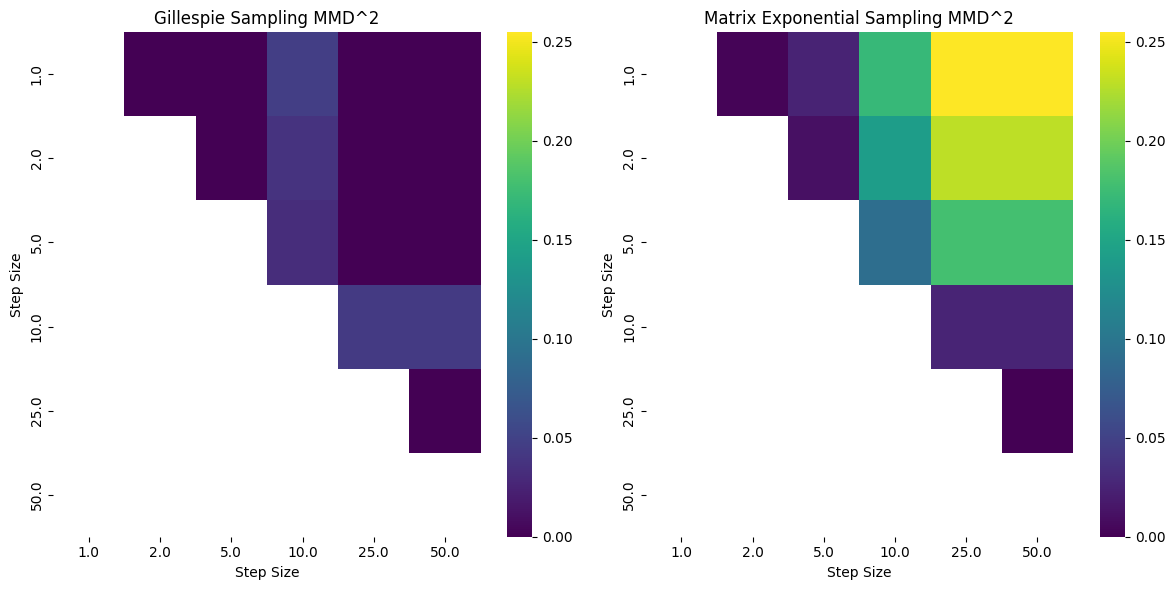

In [71]:
# plot the pairwise MMD^2 as heatmaps for each method (omit lower triangle since they are symmetric)
# share coloring scale between the two plots so they can be compared directly
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
max_mmd = max(sim_dep_mmds.max(), sim_ind_mmds.max())
sns.heatmap(sim_dep_mmds, xticklabels=step_sizes, yticklabels=step_sizes, mask=np.tril(np.ones_like(sim_dep_mmds, dtype=bool)), ax=ax[0], cmap="viridis", vmin=0, vmax=max_mmd)
ax[0].set_title("Gillespie Sampling MMD^2")
ax[0].set_xlabel("Step Size")
ax[0].set_ylabel("Step Size")
sns.heatmap(sim_ind_mmds, xticklabels=step_sizes, yticklabels=step_sizes, mask=np.tril(np.ones_like(sim_ind_mmds, dtype=bool)), ax=ax[1], cmap="viridis", vmin=0, vmax=max_mmd)
ax[1].set_title("Matrix Exponential Sampling MMD^2")
ax[1].set_xlabel("Step Size")
ax[1].set_ylabel("Step Size")
plt.tight_layout()
plt.show()

In [72]:
# save samples for each method to disk, indexed by step size using two csv files
# Create DataFrames for independent and dependent methods
ind_data = {
    "step_size": [],
    "simulated_sequence": [],
}
dep_data = {
    "step_size": [],
    "simulated_sequence": [],
}
for step_size in step_sizes:
    ind_seqs = ind_step_size_to_simulated_seqs[step_size]
    dep_seqs = dep_step_size_to_simulated_seqs[step_size]
    ind_data["step_size"].extend([step_size] * len(ind_seqs))
    ind_data["simulated_sequence"].extend(ind_seqs)
    dep_data["step_size"].extend([step_size] * len(dep_seqs))
    dep_data["simulated_sequence"].extend(dep_seqs)
    
ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)
ind_df.to_csv("results/gen_eval/ctmc_mat_exp_step_size_samples.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie_step_size_samples.csv", index=False)

### Markov Bridge Sampling to Study Endpoint Conditioned Paths

Here we sample bridge trajectories from the CTMC model conditioned on the seed sequence and the target sequence. We then fold the sequences and plot the pLDDT scores against the time points.

In [ ]:
# initialize the markov bridge sampler from the network
from peint.models.frameworks.ctmc import MarkovBridgeSampler, BridgeTrajectory
from evo.folding import run_omegafold
import random

sampler = MarkovBridgeSampler(model=net)
batch_size = dataloader.batch_size
max_substitutions = 50
num_batches = 1
print(f"Sampling {batch_size * num_batches} bridges from Markov Bridge Sampler...")

In [32]:
# sample bridge trajectories for each batch
yseqs = []
bridge_trajectories = []
naive_trajectories = []
dataloader_iter = iter(dataloader)

for idx in tqdm(range(num_batches)):
    batch = next(dataloader_iter)
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes = batch
    yseqs.extend([decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))])
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        bridges = sampler.sample(
            x=x,
            y=y,
            t=t,
            x_sizes=x_sizes,
            max_substitutions=max_substitutions,
        )
    bridge_trajectories.append(bridges)

    # create naive trajectories which is just a linear interpolation between x and y where we iteratively mutate one position at a time
    # sample times uniformly between 0 and t for each position to mutate where x and y differ
    # then sort the mutation times and apply the mutations in that order
    # return sequences, times so that i can save to a fasta file later
    for i in range(x.size(0)):
        x_seq = decode_sequence_from_toks(x[i].cpu().numpy(), skip_gap_tokens=False)
        y_seq = decode_sequence_from_toks(y[i].cpu().numpy(), skip_gap_tokens=False)
        diff_positions = [pos for pos in range(len(x_seq)) if x_seq[pos] != y_seq[pos]]
        n_diffs = len(diff_positions)
        if n_diffs == 0:
            naive_trajectories.append(BridgeTrajectory(
                sequences=[x_seq],
                times=[0.0],
            ))
            continue
        mutation_times = sorted(random.uniform(0, t[i].item()) for _ in range(n_diffs))
        sequences = [x_seq]
        times = [0.0]
        current_seq = list(x_seq)
        diff_positions = list(diff_positions)
        random.shuffle(diff_positions)
        for pos, mut_time in zip(diff_positions, mutation_times):
            current_seq[pos] = y_seq[pos]
            sequences.append("".join(current_seq))
            times.append(mut_time)
        
        sequences.append(y_seq)
        times.append(t[i].item())
            
        naive_trajectories.append(dict(
            sequences=sequences,
            times=times,
            num_events=len(sequences) - 1,
        ))
   

100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.41s/it]


In [40]:
print(sequences[-1])
print(yseqs[i])

--RGCTREFDPICGTDNLLYSNECLLCLHNLQK---SDHVRIKNRGMC---------
RGCTREFDPICGTDNLLYSNECLLCLHNLQKSDHVRIKNRGMC


In [43]:
# save the naive trajectories to fasta files like below 
os.makedirs(f"{results_dir}/bridges", exist_ok=True)
fasta_files = []

for i, traj in enumerate(naive_trajectories):
    fid = family_ids[i]
    num_events = traj['num_events']
    sequences = traj['sequences']
    sequences = [seq.replace('-', '') for seq in sequences]
    assert sequences[-1] == yseqs[i], "Final sequence does not match target sequence"
    times = traj['times']
    fasta_lines = [
        f">{time:.4f}\n{seq}\n" for time, seq in zip(times, sequences)
    ]
    fasta_filename = f"{results_dir}/bridges/{fid}_naive.fasta"
    with open(fasta_filename, "w") as f:
        f.writelines(fasta_lines)
    fasta_files.append(fasta_filename)

In [ ]:
os.makedirs(f"{results_dir}/bridges", exist_ok=True)
fasta_files = []

# save the bridge trajectories to disk as fasta files with the family id as filename and times as sequence ids
for batch_idx, bridges in tqdm(enumerate(bridge_trajectories)):
    fids = family_ids[batch_idx * batch_size: (batch_idx + 1) * batch_size]
    _yseqs = yseqs[batch_idx * batch_size: (batch_idx + 1) * batch_size]
    for b in range(batch_size):
        fid = fids[b]
        num_events = bridges.num_events[b]
        sequences = [x for x in bridges.sequences[b, :num_events]]
        sequences = [decode_sequence_from_toks(seq.cpu().numpy(), skip_gap_tokens=True) for seq in sequences]
        assert sequences[-1] == _yseqs[b], "Final sequence does not match target sequence"
        times = bridges.times[b, :num_events].tolist()
        fasta_lines = [
            f">{time:.4f}\n{seq}\n" for time, seq in zip(times, sequences)
        ]
        fasta_filename = f"{results_dir}/bridges/{fid}.fasta"
        with open(fasta_filename, "w") as f:
            f.writelines(fasta_lines)
        fasta_files.append(fasta_filename)

1it [00:00, 11.16it/s]

['5dae_1_A', '5c92_1_A', '2zu0_1_A', '1cpn_1_A', '4bji_1_A', '4dws_1_A', '19hc_1_A', '4hs2_1_B', '4bhr_1_A', '2rjz_1_B', '5c5h_1_A', '1ec5_1_A', '1f3v_1_A', '3w15_1_B', '3cs3_1_B', '3tri_1_B']


In [44]:
# fold the sequences using omegafold and extract the pLDDT scores
for fasta_filename in tqdm(fasta_files[:10]):
    print(f"Folding sequences in {fasta_filename}...")
    family_id = Path(fasta_filename).stem
    family_pdb_folder = f"{results_dir}/bridges/{family_id}"
    if os.path.exists(family_pdb_folder):
        num_pdb_files = len(list(Path(family_pdb_folder).glob("*.pdb")))
        num_sequences = sum(1 for line in open(fasta_filename) if line.startswith(">"))
        if num_pdb_files == num_sequences:
            print(f"Skipping folding for {family_id}, already exists.")
            continue
    os.makedirs(family_pdb_folder, exist_ok=True)
    run_omegafold(
        input_fasta_file=fasta_filename,
        output_structures_dir=family_pdb_folder,
    )

  0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5dae_1_A_naive.fasta...
Skipping folding for 5dae_1_A_naive, already exists.
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5c92_1_A_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5c92_1_A_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/5c92_1_A_naive


 20%|████████████████                                                                | 2/10 [01:06<04:25, 33.20s/it]

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2zu0_1_A_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2zu0_1_A_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2zu0_1_A_naive


 30%|████████████████████████                                                        | 3/10 [01:45<04:10, 35.77s/it]

...

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/4bhr_1_A_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/4bhr_1_A_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/4bhr_1_A_naive


 90%|████████████████████████████████████████████████████████████████████████        | 9/10 [09:53<01:12, 72.03s/it]

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges
Folding sequences in /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2rjz_1_B_naive.fasta...
Running OmegaFold command: omegafold /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2rjz_1_B_naive.fasta /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges/2rjz_1_B_naive


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [11:07<00:00, 66.73s/it]

OmegaFold structure prediction completed for /scratch/users/stephen.lu/projects/protevo/paper/2025-12-13/bridges


In [45]:
# for the folded structures, extract the pLDDT scores and plot them against the time points
import glob
import biotite.structure.io as bsio

plddt_data = {
    "family_id": [],
    "plddt": [],
    "time": [],
    "method": [],
}
fasta_files = glob.glob(f"{results_dir}/bridges/*.fasta")

for fasta_filename in tqdm(fasta_files):
    family_id = Path(fasta_filename).stem
    is_naive = family_id.endswith("_naive")
    family_pdb_folder = f"{results_dir}/bridges/{family_id}"
    if not os.path.exists(family_pdb_folder):
        continue
    pdb_files = glob.glob(f"{family_pdb_folder}/*.pdb")
    for pdb_file in pdb_files:
        time_point = float(Path(pdb_file).stem)
        structure = bsio.load_structure(pdb_file, extra_fields=['b_factor'])
        plddt = structure.b_factor.mean()
        plddt_data["family_id"].append(family_id)
        plddt_data["time"].append(time_point)
        plddt_data["plddt"].append(plddt)
        plddt_data["method"].append("omegafold" if not is_naive else "naive")

plddt_df = pd.DataFrame(plddt_data)

100%|███████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 12.03it/s]


In [47]:
# for each family, re-normalize the times to be between 0 and 1
plddt_df['norm_time'] = plddt_df.groupby('family_id')['time'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# add a flag for real sequences which should be the first and last time points in each family
plddt_df['is_real'] = plddt_df.groupby('family_id')['time'].transform(lambda x: x.isin([x.min(), x.max()]))

In [49]:
plddt_real_endpoints = plddt_df[(plddt_df['is_real']) & (plddt_df['method'] == 'omegafold')]

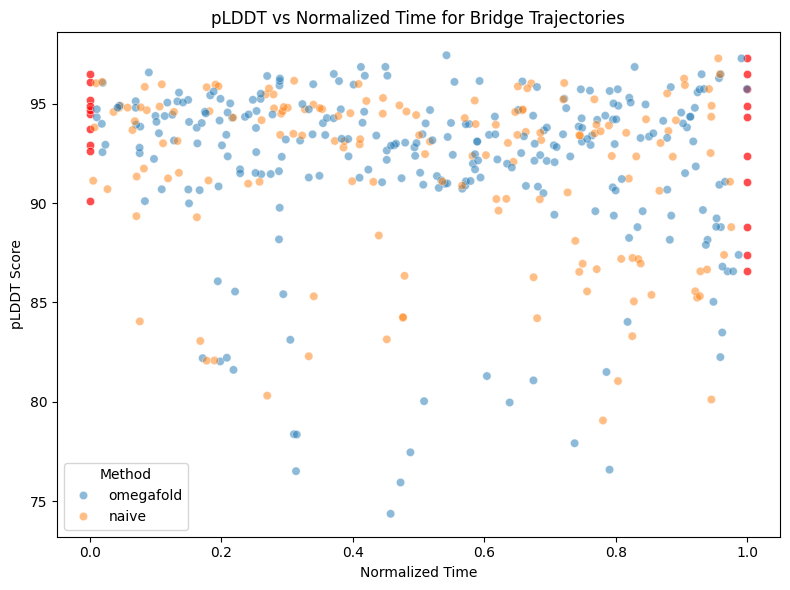

In [53]:
# plot pLDDT against normalized time for real endpoint sequences only
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plddt_real_endpoints, 
    x='norm_time', 
    y='plddt', 
    color='red',
    ax=ax,
    alpha=0.7,
    # s=100
)

# now plot non_real sequences with different colors for naive and omegafold
sns.scatterplot(
    data=plddt_df[~plddt_df['is_real']], 
    x='norm_time', 
    y='plddt', 
    hue='method',
    ax=ax,
    alpha=0.5,
    # s=80
)

ax.set_title("pLDDT vs Normalized Time for Bridge Trajectories")
ax.set_xlabel("Normalized Time")
ax.set_ylabel("pLDDT Score")
ax.legend(title='Method')
plt.tight_layout()
plt.show()

## Variant Effect Prediction
Using the Koenig Dataset for Antibody Jaffe. In this experiment, we evaluate the performance of the CTMC model to perform variant effect prediction on the Koenig dataset. We regress out the somatic hypermutation rates from the trained model in order to isolate the selection effects of the mutations.

In [282]:
from typing import List, Dict
import tempfile

import numpy as np
from scipy.stats import pearsonr
from scipy.special import logsumexp
import matplotlib.patches as mpatches

from netam import pretrained
from netam.framework import Crepe
from netam.models import IndepRSCNNModel
from netam.molevol import neutral_codon_probs_of_seq
from netam.sequences import CODONS, CODON_TO_INDEX, AMBIGUOUS_CODON_IDX

from evo.sequence import get_mutant
from evo.tokenization import CodonVocab
from evo.dms import get_site_by_site_consensus
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ, parallel_align_sequences

# Scaling Factor relating PEINT trained branch lengths to standard phylogenetic branch lengths
BL_CORRECTION = 42.517871366

In [283]:
def get_codons_from_mut(mut: str) -> List[str]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in CodonVocab.GENETIC_CODE.items() if v == new_aa]
    return codons

def compute_edit_distance_of_codon_mut(wt_nucleotide_seq: str, aa_mut: str) -> List[int]:
    wt_aa, pos, new_aa = aa_mut[:1], int(aa_mut[1:-1]), aa_mut[-1:]
    codons = get_codons_from_mut(aa_mut)
    nt_pos = pos * 3
    wt_codon = wt_nucleotide_seq[nt_pos:nt_pos+3]
    edit_distances = [sum(c1 != c2 for c1, c2 in zip(wt_codon, codon)) for codon in codons]
    return edit_distances

def compute_codon_probs(codon_idxs: torch.Tensor, codon_probs: torch.Tensor) -> float:
    # codon_idxs is a 1d tensor of codon indices (seq_len,) and codon_probs is a 2d tensor of shape (seq_len, num_codons)
    return codon_probs[torch.arange(codon_idxs.size(0)), codon_idxs].sum().item()

def compute_mutant_codon_probs(wt_codon_idxs: torch.Tensor, mut: str, codon_probs: torch.Tensor) -> List[float]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = get_codons_from_mut(mut)
    mt_codon_idxs = [CODON_TO_INDEX[codon] for codon in codons]
    mt_codon_seq_probs = []
    for mt_codon_idx in mt_codon_idxs:
        mutant_codon_idxs = wt_codon_idxs.clone()
        mutant_codon_idxs[pos] = mt_codon_idx
        mutant_codon_prob = compute_codon_probs(mutant_codon_idxs, codon_probs)
        mt_codon_seq_probs.append(mutant_codon_prob )
    return mt_codon_seq_probs

In [325]:
# Load and preprocess the Koenig dataset
# df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms/Koenig2017_g6_er.csv")
# dms_study = "Koenig2017_g6_er"
df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms/Koenig2017_g6_binding_old.csv")
dms_study = "Koenig2017_g6_binding_old"

df = df[['heavy', 'light', 'fitness']]
heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

if IS_AHO:
    aho_heavy_wt = parallel_align_sequences([("koenig_heavy_wt", heavy_wt)], chunk_size=1, n_jobs=1)[0][1]
    aho_light_wt = parallel_align_sequences([("koenig_light_wt", light_wt)], chunk_size=1, n_jobs=1)[0][1][:-1]
    df_aho_heavy_col = parallel_align_sequences(df['heavy'].apply(lambda x: (f"koenig_heavy_wt", x)).tolist(), chunk_size=32, n_jobs=4, verbose=False)
    df_aho_light_col = parallel_align_sequences(df['light'].apply(lambda x: (f"koenig_light_wt", x)).tolist(), chunk_size=32, n_jobs=4, verbose=False)
    df['aho_heavy'] = [x[1] for x in df_aho_heavy_col]
    df['aho_light'] = [x[1][:-1] for x in df_aho_light_col]

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))

df_heavy = df[df['heavy_mut'] != '']
df_light = df[df['light_mut'] != '']
df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
df_light.rename(columns={'light_mut': 'mut'}, inplace=True)
df_heavy.set_index('mut', inplace=True)
df_light.set_index('mut', inplace=True)

heavy_mut_codes = df_heavy.index.values.tolist()
light_mut_codes = df_light.index.values.tolist()

print(df_heavy.shape, df_light.shape)
print(len(df_heavy) + len(df_light))

120 108 228
(2261, 4) (2014, 4)
4275


/tmp/ipykernel_1245360/894256211.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
/tmp/ipykernel_1245360/894256211.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light.rename(columns={'light_mut': 'mut'}, inplace=True)


In [ ]:
# hyperparameters
# CTMC_BLS = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
CTMC_BLS = [np.inf, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 2.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0]
RAW_CODON_BLS = [8, 9, 10, 11, 12, 12.5, 13, 13.5, 14]

# codon neutral model correction params (optional)
MULTIHIT = True
CODON_BLS = [bl/BL_CORRECTION for bl in RAW_CODON_BLS]

In [ ]:
# save the log likelihoods for each mutation and branch length
hv_ll_dict = {bl: defaultdict(float) for bl in CTMC_BLS}
lt_ll_dict = {bl: defaultdict(float) for bl in CTMC_BLS}

# save the codon log likelihoods for each mutation and branch length
shm_hv_probs_dict = {bl: defaultdict(list) for bl in CODON_BLS}
shm_lt_probs_dict = {bl: defaultdict(list) for bl in CODON_BLS}

# save the codon edit distance for each mutation
shm_hv_ed_dict = defaultdict(float)
shm_lt_ed_dict = defaultdict(float)

In [317]:
# infer log likelihoods for heavy and light chains with the CTMC trained model
for BL in CTMC_BLS:
    print(f"Evaluating CTMC with branch length {BL}")

    if IS_AHO:
        hv_transitions = [f"{aho_heavy_wt}.{aho_light_wt} {row['aho_heavy']}.{aho_light_wt} {BL}" for i, row in df_heavy.iterrows()]
        lt_transitions = [f"{aho_heavy_wt}.{aho_light_wt} {aho_heavy_wt}.{row['aho_light']} {BL}" for i, row in df_light.iterrows()]
    else:
        hv_transitions = [f"{heavy_wt}.{light_wt} {row['heavy']}.{light_wt} {BL}" for i, row in df_heavy.iterrows()]
        lt_transitions = [f"{heavy_wt}.{light_wt} {heavy_wt}.{row['light']} {BL}" for i, row in df_light.iterrows()]

    hv_muts = [row.name for i, row in df_heavy.iterrows()]
    lt_muts = [row.name for i, row in df_light.iterrows()]
    
    # make temporary file for transitions
    hv_datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(hv_datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(hv_transitions)))
        f.write("\n".join(hv_transitions))

    lt_datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(lt_datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(lt_transitions)))
        f.write("\n".join(lt_transitions))

    hv_dataset = ComplexCherriesDataset(data_file=hv_datafile.name, min_t=0., chain_id_offset=1)
    hv_dataloader = dataloader_from_dataset(dataset=hv_dataset, batch_size=32, num_workers=4)

    lt_dataset = ComplexCherriesDataset(data_file=lt_datafile.name, min_t=0., chain_id_offset=1)
    lt_dataloader = dataloader_from_dataset(dataset=lt_dataset, batch_size=32, num_workers=4)

    print(f"Number of batches in heavy chain dataloader: {len(hv_dataloader)}")
    print(f"Number of batches in light chain dataloader: {len(lt_dataloader)}")

    use_stationary = True if BL == np.inf else False
    hv_lls, _, hv_ppls = infer_log_likelihoods(dataloader=hv_dataloader, net=net, n_batches=-1, ignore_gaps_in_y=False, use_stationary=use_stationary)
    lt_lls, _, lt_ppls = infer_log_likelihoods(dataloader=lt_dataloader, net=net, n_batches=-1, ignore_gaps_in_y=False, use_stationary=use_stationary)
    
    for hv_mut, hv_ll in zip(hv_muts, hv_lls):
        hv_ll_dict[BL][hv_mut] = hv_ll

    for lt_mut, lt_ll in zip(lt_muts, lt_lls):
        lt_ll_dict[BL][lt_mut] = lt_ll

Evaluating CTMC with branch length inf
Number of batches in heavy chain dataloader: 71
Number of batches in light chain dataloader: 63


Inference: 100%|███████████████████████████████████████████████████████████████| 63/63 [00:04<00:00, 14.28it/s]


### Apply neutral model correction (optional)

In [303]:
# Load the neutral thrifty model
crepe = pretrained.load("ThriftyHumV0.2-45")
multihit_model = pretrained.load_multihit("ThriftyHumV0.2-59-hc-tangshm", device="cpu")

Loading model ThriftyHumV0.2-45
Using cached models: /accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/netam/_pretrained/thrifty-0.2.0.zip
Loading multihit model ThriftyHumV0.2-59-hc-tangshm


In [304]:
# Compute neutral codon substitution probabilities for the wildtype sequences
nt_rates, csp_logits = crepe([KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ])
csps = torch.softmax(csp_logits, dim=-1)

heavy_nt_rates, heavy_csps = nt_rates[0], csps[0]
light_nt_rates, light_csps = nt_rates[1], csps[1]
heavy_mask = torch.zeros_like(heavy_nt_rates, dtype=torch.bool)
light_mask = torch.zeros_like(light_nt_rates, dtype=torch.bool)
heavy_mask[:len(KOENIG_IGH_CON_SEQ)] = True
light_mask[:len(KOENIG_IGK_CON_SEQ)] = True

hv_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGH_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGH_CON_SEQ), 3)]
lt_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGK_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGK_CON_SEQ), 3)]
hv_wt_codon_idxs = torch.tensor(hv_wt_codon_idxs, dtype=torch.long)
lt_wt_codon_idxs = torch.tensor(lt_wt_codon_idxs, dtype=torch.long)

In [305]:
# for each possible single amino acid change in the heavy chain, compute the log probability of that change under the heavy_codon_probs
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

for bl_idx, BL in enumerate(CODON_BLS):
    print(f"Computing codon probabilities for branch length {BL}")

    heavy_codon_probs = torch.log(neutral_codon_probs_of_seq(
        KOENIG_IGH_CON_SEQ, heavy_mask, heavy_nt_rates,
        heavy_csps, BL, multihit_model=multihit_model if MULTIHIT else None,
    ))
    light_codon_probs = torch.log(neutral_codon_probs_of_seq(
        KOENIG_IGK_CON_SEQ, light_mask, light_nt_rates,
        light_csps, BL, multihit_model=multihit_model if MULTIHIT else None,
    ))
    assert len(hv_wt_codon_idxs) == len(heavy_codon_probs)
    assert len(lt_wt_codon_idxs) == len(light_codon_probs)

    for i, row in tqdm(df_heavy.iterrows(), desc="Heavy Chain SHM LLs"):
        mut_code = row.name
        wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
        mt_codon_seq_probs = compute_mutant_codon_probs(hv_wt_codon_idxs, mut_code, heavy_codon_probs)
        shm_hv_probs_dict[BL][mut_code] = mt_codon_seq_probs
        if bl_idx == 0:
            shm_hv_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGH_CON_SEQ, mut_code)

    for i, row in tqdm(df_light.iterrows(), desc="Light Chain SHM LLs"):
        mut_code = row.name
        wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
        mt_codon_seq_probs = compute_mutant_codon_probs(lt_wt_codon_idxs, mut_code, light_codon_probs)
        shm_lt_probs_dict[BL][mut_code] = mt_codon_seq_probs
        if bl_idx == 0:
            shm_lt_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGK_CON_SEQ, mut_code)

Computing codon probabilities for branch length 0.18815617393295256


Heavy Chain SHM LLs: 2261it [00:00, 5765.40it/s]
Light Chain SHM LLs: 2014it [00:00, 5886.25it/s]


Computing codon probabilities for branch length 0.21167569567457165


Heavy Chain SHM LLs: 2261it [00:00, 6113.38it/s]
Light Chain SHM LLs: 2014it [00:00, 6226.21it/s]


Computing codon probabilities for branch length 0.2351952174161907


...

Heavy Chain SHM LLs: 2261it [00:00, 6148.28it/s]
Light Chain SHM LLs: 2014it [00:00, 6320.50it/s]


Computing codon probabilities for branch length 0.31751354351185745


Heavy Chain SHM LLs: 2261it [00:00, 6199.17it/s]
Light Chain SHM LLs: 2014it [00:00, 6275.11it/s]


Computing codon probabilities for branch length 0.329273304382667


Heavy Chain SHM LLs: 2261it [00:00, 6210.79it/s]
Light Chain SHM LLs: 2014it [00:00, 6285.97it/s]


In [326]:
# logsumexp over lls and take min over edit distances
shm_hv_ll_final_dict = {bl: {k: np.logaddexp.reduce(v) for k, v in d.items()} for bl, d in shm_hv_probs_dict.items()}
shm_lt_ll_final_dict = {bl: {k: np.logaddexp.reduce(v) for k, v in d.items()} for bl, d in shm_lt_probs_dict.items()}
shm_hv_ed_final_dict = {k: min(v) for k, v in shm_hv_ed_dict.items()}
shm_lt_ed_final_dict = {k: min(v) for k, v in shm_lt_ed_dict.items()}

# add the computed log probabilities back to the dataframes
for mut_code in df_heavy.index:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        df_heavy.loc[mut_code, 'shm_edit_distance'] = shm_hv_ed_final_dict[mut_code]

for mut_code in df_light.index:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        df_light.loc[mut_code, 'shm_edit_distance'] = shm_lt_ed_final_dict[mut_code]

/tmp/ipykernel_1245360/1082985314.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.loc[mut_code, 'shm_edit_distance'] = shm_hv_ed_final_dict[mut_code]
/tmp/ipykernel_1245360/1082985314.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light.loc[mut_code, 'shm_edit_distance'] = shm_lt_ed_final_dict[mut_code]


### Calculate final perplexities on Koenig and plot results

In [327]:
def compute_perplexities(
    shm_probs_dict,
    ll_dict,
    df: pd.DataFrame,
    wt_seq: str,
    ctmc_bl: float,
    null_bl: float | None = None
):
    _ll_key = f"ll_{ctmc_bl}_{null_bl:.2f}" if null_bl is not None else f"ll_{ctmc_bl}"
    _ppl_key = f"ppl_{ctmc_bl}_{null_bl:.2f}" if null_bl is not None else f"ppl_{ctmc_bl}"
    _corrected_ll_key = f"corrected_{_ll_key}" if null_bl is not None else f"corrected_{_ll_key}"
    _corrected_ppl_key = f"corrected_{_ppl_key}" if null_bl is not None else f"corrected_{_ppl_key}"
    _shm_probs_dict = shm_probs_dict[null_bl] if null_bl is not None else {}
    _ll_dict = ll_dict[ctmc_bl]        
    for mut, ll in _ll_dict.items():
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            ppl = np.exp(-ll / len(wt_seq))
            df.loc[mut, _ll_key] = ll
            df.loc[mut, _ppl_key] = ppl
            if not null_bl:
                continue
            try:
                shm_lls = np.array(_shm_probs_dict[mut])
                corrected_ll = ll - logsumexp(shm_lls)
                corrected_ppl = np.exp(-corrected_ll / len(wt_seq))
                df.loc[mut, _corrected_ll_key] = corrected_ll
                df.loc[mut, _corrected_ppl_key] = corrected_ppl
            except NameError as e:
                print("Skipping Neutral Mutation Correction")
                df.loc[mut, _corrected_ll_key] = None
                df.loc[mut, _corrected_ppl_key] = None
            except e:
                raise e
    return df

In [328]:
warnings.filterwarnings("ignore", category=UserWarning)

# Heavy Chain
for ctmc_bl in CTMC_BLS:
    print(f"Computing perplexities for heavy chain CTMC BL {ctmc_bl}")
    df_heavy = compute_perplexities(shm_hv_probs_dict, hv_ll_dict, df_heavy, heavy_wt, ctmc_bl, null_bl=None).copy()
    for null_bl in CODON_BLS:
        df_heavy = compute_perplexities(shm_hv_probs_dict, hv_ll_dict, df_heavy, heavy_wt, ctmc_bl, null_bl).copy()

# Light Chain
for ctmc_bl in CTMC_BLS:
    print(f"Computing perplexities for light chain CTMC BL {ctmc_bl}")
    df_light = compute_perplexities(shm_lt_probs_dict, lt_ll_dict, df_light, light_wt, ctmc_bl, null_bl=None).copy()
    for null_bl in CODON_BLS:
        df_light = compute_perplexities(shm_lt_probs_dict, lt_ll_dict, df_light, light_wt, ctmc_bl, null_bl).copy()

for ctmc_bl in CTMC_BLS:
    df_heavy[f'ppl_{ctmc_bl}'] = df_heavy[f'ppl_{ctmc_bl}'].astype(float)
    df_light[f'ppl_{ctmc_bl}'] = df_light[f'ppl_{ctmc_bl}'].astype(float)
    for null_bl in CODON_BLS:
        _ppl_key = f"ppl_{ctmc_bl}_{null_bl:.2f}"
        df_heavy[f'corrected_{_ppl_key}'] = df_heavy[f'corrected_{_ppl_key}'].astype(float)
        df_light[f'corrected_{_ppl_key}'] = df_light[f'corrected_{_ppl_key}'].astype(float)

Computing perplexities for heavy chain CTMC BL inf


/tmp/ipykernel_1245360/2267259563.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mut, _ll_key] = ll
/tmp/ipykernel_1245360/2267259563.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mut, _ppl_key] = ppl


Computing perplexities for heavy chain CTMC BL 0.1
Computing perplexities for heavy chain CTMC BL 0.3
Computing perplexities for heavy chain CTMC BL 0.5
Computing perplexities for heavy chain CTMC BL 0.7
Computing perplexities for heavy chain CTMC BL 0.9
Computing perplexities for heavy chain CTMC BL 1.1
Computing perplexities for heavy chain CTMC BL 2.0
Computing perplexities for heavy chain CTMC BL 5.0
Computing perplexities for heavy chain CTMC BL 10.0
Computing perplexities for heavy chain CTMC BL 20.0
Computing perplexities for heavy chain CTMC BL 30.0
Computing perplexities for heavy chain CTMC BL 40.0
Computing perplexities for heavy chain CTMC BL 50.0
Computing perplexities for light chain CTMC BL inf


/tmp/ipykernel_1245360/2267259563.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mut, _ll_key] = ll
/tmp/ipykernel_1245360/2267259563.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mut, _ppl_key] = ppl


Computing perplexities for light chain CTMC BL 0.1
Computing perplexities for light chain CTMC BL 0.3
Computing perplexities for light chain CTMC BL 0.5
Computing perplexities for light chain CTMC BL 0.7
Computing perplexities for light chain CTMC BL 0.9
Computing perplexities for light chain CTMC BL 1.1
Computing perplexities for light chain CTMC BL 2.0
Computing perplexities for light chain CTMC BL 5.0
Computing perplexities for light chain CTMC BL 10.0
Computing perplexities for light chain CTMC BL 20.0
Computing perplexities for light chain CTMC BL 30.0
Computing perplexities for light chain CTMC BL 40.0
Computing perplexities for light chain CTMC BL 50.0


In [331]:
# save the df_heavy and df_light dataframes to disk
df_heavy.to_csv(f"{results_dir}/df_heavy_{dms_study}.csv", index=False)
df_light.to_csv(f"{results_dir}/df_light_{dms_study}.csv", index=False)

### Plotting Results

In [49]:
# load the df_heavy and df_light dataframes from disk (if they exist)
if os.path.exists(f"{results_dir}/df_heavy_{dms_study}.csv"):
    df_heavy = pd.read_csv(f"{results_dir}/df_heavy_{dms_study}.csv")
if os.path.exists(f"{results_dir}/df_light_{dms_study}.csv"):
    df_light = pd.read_csv(f"{results_dir}/df_light_{dms_study}.csv")

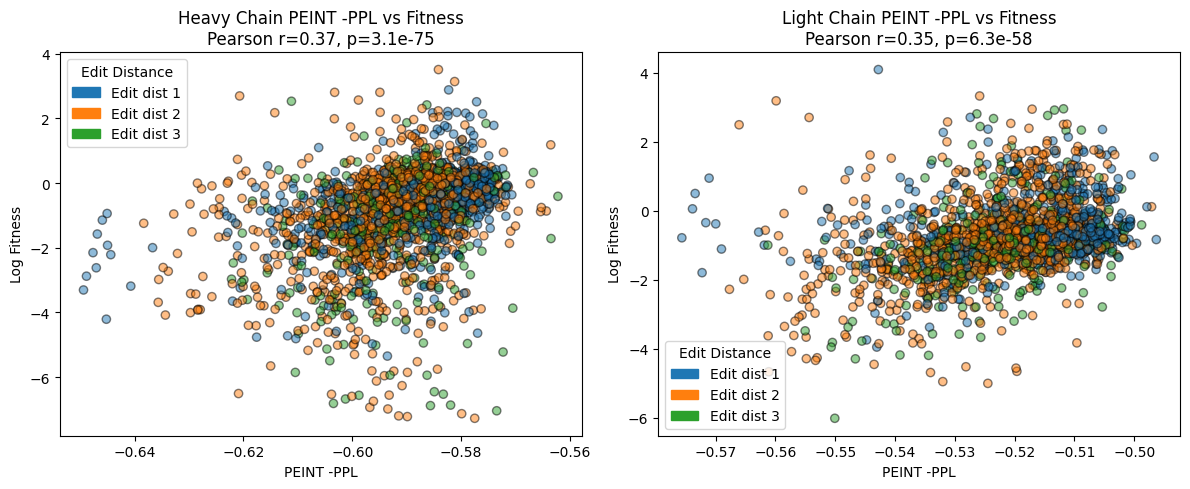

In [335]:
NEUTRAL_MUTATION_CORRECTION = True
CTMC_BL = 0.1
CODON_BL = 12.5/BL_CORRECTION

ppl_column = f'corrected_ppl_{CTMC_BL}_{CODON_BL:.2f}' if NEUTRAL_MUTATION_CORRECTION else f'ppl_{CTMC_BL}_{CODON_BL:.2f}'

# Calculate Pearson correlation for heavy and light chains
hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))

# plot ll vs fitness for heavy and light chains, colored by edit distance, and show Pearson r
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

if NEUTRAL_MUTATION_CORRECTION:
    unique_edits_hv = sorted(df_heavy['shm_edit_distance'].dropna().unique())
    cmap = plt.get_cmap('tab10')
    cdict_hv = {ed: cmap(i % 10) for i, ed in enumerate(unique_edits_hv)}
    colors_hv = df_heavy['shm_edit_distance'].map(cdict_hv)

    scatter_hv = ax[0].scatter(
        -df_heavy[ppl_column],
        np.log(df_heavy['fitness']),
        c=colors_hv,
        edgecolor='black',
        alpha=0.5
    )
    handles_hv = [
        mpatches.Patch(color=cdict_hv[ed], label=f'Edit dist {int(ed)}')
        for ed in unique_edits_hv
    ]
    ax[0].legend(handles=handles_hv, title="Edit Distance")

    unique_edits_lt = sorted(df_light['shm_edit_distance'].dropna().unique())
    cdict_lt = {ed: cmap(i % 10) for i, ed in enumerate(unique_edits_lt)}
    colors_lt = df_light['shm_edit_distance'].map(cdict_lt)

    scatter_lt = ax[1].scatter(
        -df_light[ppl_column],
        np.log(df_light['fitness']),
        c=colors_lt,
        edgecolor='black',
        alpha=0.5
    )
    handles_lt = [
        mpatches.Patch(color=cdict_lt[ed], label=f'Edit dist {int(ed)}')
        for ed in unique_edits_lt
    ]
    ax[1].legend(handles=handles_lt, title="Edit Distance")
else:
    ax[0].scatter(-df_heavy[ppl_column], np.log(df_heavy['fitness']), edgecolor='black', alpha=0.5)
    ax[1].scatter(-df_light[ppl_column], np.log(df_light['fitness']), edgecolor='black', alpha=0.5)

ax[0].set_title(f'Heavy Chain PEINT -PPL vs Fitness\nPearson r={hv_corr:.2f}, p={hv_pval:.2g}')
ax[0].set_xlabel('PEINT -PPL')
ax[0].set_ylabel('Log Fitness')

ax[1].set_title(f'Light Chain PEINT -PPL vs Fitness\nPearson r={lt_corr:.2f}, p={lt_pval:.2g}')
ax[1].set_xlabel('PEINT -PPL')
ax[1].set_ylabel('Log Fitness')

plt.tight_layout()
plt.show()

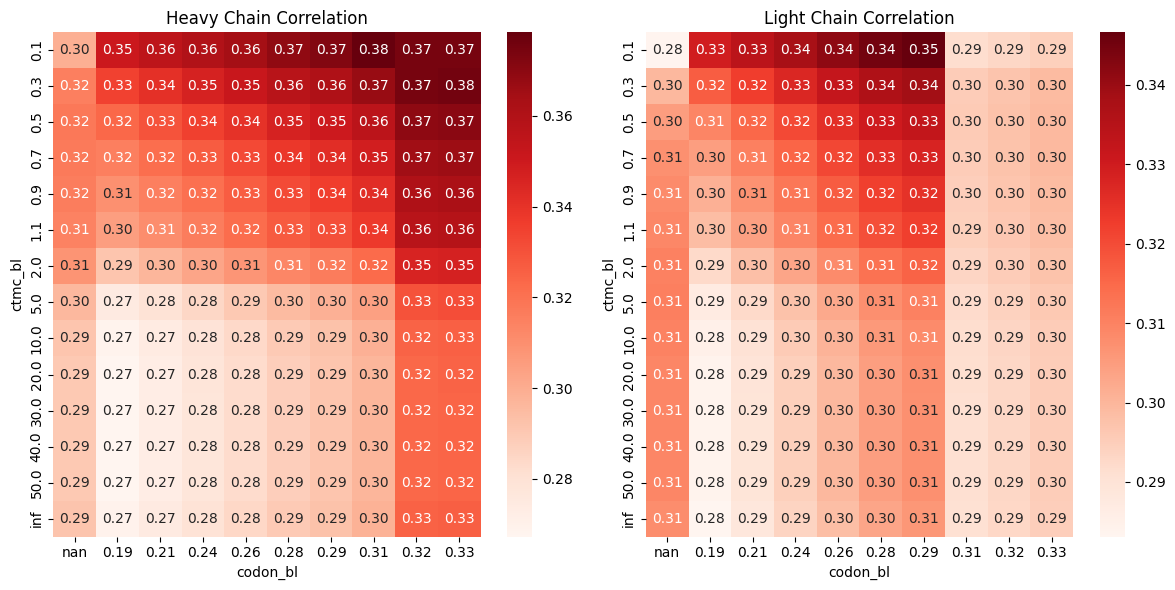

In [330]:
# for each combination of CTMC_BL and CODON_BL, compute the Pearson correlation between the perplexities and fitness
data = []

for ctmc_bl in CTMC_BLS:
    ppl_column = f"ppl_{ctmc_bl}"
    hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
    lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))
    data.extend([
        {"chain": "heavy", "ctmc_bl": ctmc_bl, "codon_bl": None, "corr": hv_corr, "pval": hv_pval},
        {"chain": "light", "ctmc_bl": ctmc_bl, "codon_bl": None, "corr": lt_corr, "pval": lt_pval}
    ])
    for codon_bl in CODON_BLS:
        ppl_column = f'corrected_ppl_{ctmc_bl}_{codon_bl:.2f}'
        hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
        lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))
        data.extend([
            {"chain": "heavy", "ctmc_bl": ctmc_bl, "codon_bl": round(codon_bl, 2), "corr": hv_corr, "pval": hv_pval},
            {"chain": "light", "ctmc_bl": ctmc_bl, "codon_bl": round(codon_bl, 2), "corr": lt_corr, "pval": lt_pval}
        ])
        
# plot a heatmap of the correlations where the x-axis is the CTMC BL, the y-axis is the CODON BL, and the color is the correlation
# use seaborn heatmap. Plot two heatmaps side by side, one for heavy and one for light
df = pd.DataFrame(data)
heavy_corr = df[df['chain'] == 'heavy'].pivot(index='ctmc_bl', columns='codon_bl', values='corr')
light_corr = df[df['chain'] == 'light'].pivot(index='ctmc_bl', columns='codon_bl', values='corr')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Now pass the pivoted dataframes directly (use single color gradient)
# annotate but only show to 2 decimal places
sns.heatmap(heavy_corr, ax=ax[0], annot=True, cmap='Reds', fmt='.2f')
sns.heatmap(light_corr, ax=ax[1], annot=True, cmap='Reds', fmt='.2f')

ax[0].set_title('Heavy Chain Correlation')
ax[1].set_title('Light Chain Correlation')

plt.tight_layout()
plt.show()

## Interpretability Experiments
### Examining the Stationary Distribution

In this experiment, we explore the stationary distributions predicted by the CTMC model at each site. We will do this for the Koenig consensus sequence and check if this distribution matches the known entropy in the sequence (ex: CDR vs FR regions). We will also see if we can use log-likelihood ratios in the stationary distribution to predict the fitness of the sequence.

In [336]:
def align_region_masks_with_wt(aligned_wt: str, region_to_mask: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    # Align the masks with the wildtype sequence by setting gaps to False in new masks
    mask_len = len(region_to_mask["FR1"])
    if len(aligned_wt) == mask_len:
        return region_to_mask
    non_gap_mask = np.zeros(len(aligned_wt), dtype=bool)
    non_gap_mask[np.where(np.array(list(aligned_wt)) != "-")] = True
    assert np.sum(non_gap_mask) == mask_len, f"Mask length mismatch: {np.sum(non_gap_mask)} != {mask_len}"
    new_region_to_mask = {}
    for region, mask in region_to_mask.items():
        region_mask = np.zeros(len(aligned_wt), dtype=bool)
        region_mask[non_gap_mask] = mask
        # make sure the mask is contiguous, or else set True to everything between the first and last True
        first_true = np.where(region_mask)[0][0]
        last_true = np.where(region_mask)[0][-1]
        region_mask[first_true:last_true] = True
        new_region_to_mask[region] = region_mask
    return new_region_to_mask

In [341]:
# Load and preprocess the Koenig dataset to get a batched wildtype sequence
from evo.antibody import create_region_masks, parallel_align_sequences
from evo.sequence import _AA_STR_SORTED

USE_STATIONARY = False
USE_REGION_MASKS = True
VOCABULARY = _AA_STR_SORTED
# VOCABULARY = _AA_STR_SORTED + "-"

In [353]:
# process the wildtype starting sequence
# get the wildtype sequence for heavy and light chains from koenig dataset
# df = pd.read_csv("/scratch/users/aakarshv/peint_antibody/dms/Koenig2017_g6_er.csv")
# df = df[['heavy', 'light', 'fitness']]
# heavy_wt = get_site_by_site_consensus(df, "heavy").strip()
# light_wt = get_site_by_site_consensus(df, "light").strip()
# if IS_AHO:
#     heavy_wt = parallel_align_sequences([("koenig_heavy_wt", heavy_wt)], chunk_size=1, n_jobs=1)[0][1]
#     light_wt = parallel_align_sequences([("koenig_light_wt", light_wt)], chunk_size=1, n_jobs=1)[0][1][:-1]

# get the wildtype sequence for heavy and light chains from wyatt dataset test donor 4
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/aho/d4.txt")
dataset = ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1)
xs, *_ = dataset[0]
heavy_wt, light_wt = xs[0], xs[1]

if USE_REGION_MASKS:
    # get the region masks for the heavy and light chains
    unaligned_heavy_wt = heavy_wt.replace("-", "")
    unaligned_light_wt = light_wt.replace("-", "")
    heavy_region_to_mask = create_region_masks(unaligned_heavy_wt)
    light_region_to_mask = create_region_masks(unaligned_light_wt)
    heavy_region_to_mask = align_region_masks_with_wt(heavy_wt, heavy_region_to_mask)
    light_region_to_mask = align_region_masks_with_wt(light_wt, light_region_to_mask)

# create a batch of size 1 with the wildtype sequence
xs = [heavy_wt, light_wt]
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

# reshape to bs of 1 and move to device
xs = xs.unsqueeze(0).to(device)
x_sizes = x_sizes.unsqueeze(0).to(device)

print(f"Wildtype hv Sequence: {heavy_wt}")
print(f"Wildtype lt Sequence: {light_wt}")
print(f"Lengths: {len(heavy_wt)}, {len(light_wt)}")
print(f"Shape: {xs.shape}, {x_sizes.shape}")

Wildtype hv Sequence: QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLEWVAVIWYDGSNKYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDLWDSGFKFLDYWGQGTLVTVSS
Wildtype lt Sequence: EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPRLLIYGASSRATGIPDRFSGSGSGTDFTLTISRLEPEDFAVYYCQQYGSSPPYTFGQGTKLEIK
Lengths: 121, 109
Shape: torch.Size([1, 233]), torch.Size([1, 233])


In [358]:
# get the per-site stationary distribution for the wildtype sequence
with (torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16)):
    Q, pi = net(xs, x_sizes=x_sizes)  # (1, L, V, V)
    if USE_STATIONARY:
        pi = pi.squeeze(0).detach().cpu().numpy()
    else:
        t = torch.tensor([0.05], dtype=torch.float32, device=device).reshape(1, 1)
        P: Tensor = net.exp_Qt(Q, t)
        log_probs: Tensor = net.log_Px(P, xs)    # (B, L, V)
        pi = log_probs.exp().squeeze(0).detach().cpu().numpy()

# only keep standard amino acids in pi and match to heavy and light chains
pi = pi[:, vocab.standard_token_indices(standard_tokens=VOCABULARY)]
pi = pi / pi.sum(axis=-1, keepdims=True)

pi_heavy = pi[vocab.prepend_bos:len(heavy_wt) + vocab.prepend_bos]
pi_light = pi[len(heavy_wt) + vocab.prepend_bos + 1:-vocab.append_eos] # add 1 for the separator dot .

print(pi_heavy.shape, pi_light.shape)
print(len(heavy_wt), len(light_wt))

(121, 20) (109, 20)
121 109


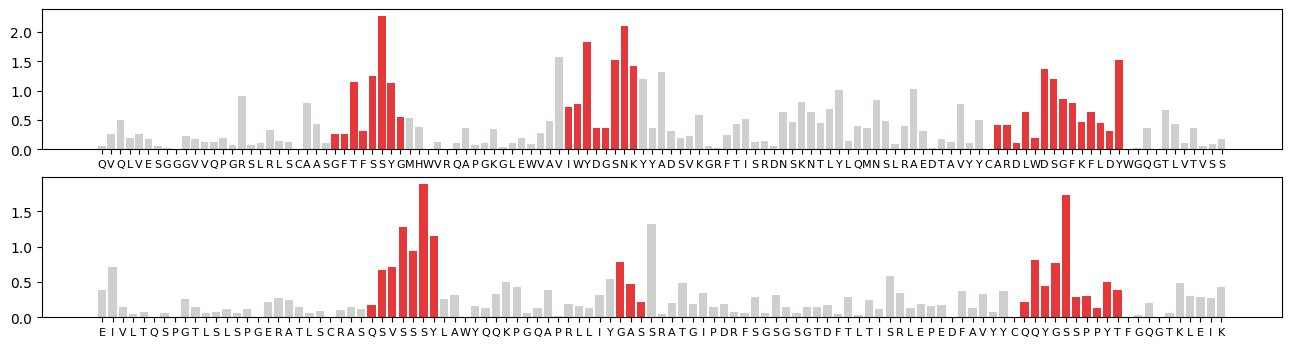

In [359]:
# calculate the entropy of each site in pi and plot a histogram of the entropies
pi_heavy_entropy = -pi_heavy * np.log2(pi_heavy)
pi_light_entropy = -pi_light * np.log2(pi_light)
pi_heavy_entropy = pi_heavy_entropy.sum(axis=-1)
pi_light_entropy = pi_light_entropy.sum(axis=-1)

cdr_color = "#e5383b"
fr_color = "#ced0ce"

# color the CDR regions in the histogram in red in the background please
if USE_REGION_MASKS:
    heavy_cdr_mask = heavy_region_to_mask['CDR1'] | heavy_region_to_mask['CDR2'] | heavy_region_to_mask['CDR3']
    light_cdr_mask = light_region_to_mask['CDR1'] | light_region_to_mask['CDR2'] | light_region_to_mask['CDR3']
    heavy_colors = [fr_color if not cdr else cdr_color for cdr in heavy_cdr_mask]
    light_colors = [fr_color if not cdr else cdr_color for cdr in light_cdr_mask]
else:
    heavy_colors = fr_color
    light_colors = fr_color

# make a per-site entropy bar plot with the CDR regions colored in red
fig, ax = plt.subplots(2, 1, figsize=(16, 4))
ax[0].bar(range(len(pi_heavy_entropy)), pi_heavy_entropy, color=heavy_colors)
ax[1].bar(range(len(pi_light_entropy)), pi_light_entropy, color=light_colors)

# set the x-axis ticks to the actual amino acid letters and gap characters found in the heavy_wt and light_wt sequences
ax[0].set_xticks(range(len(heavy_wt)))
ax[1].set_xticks(range(len(light_wt)))
ax[0].set_xticklabels(heavy_wt)
ax[1].set_xticklabels(light_wt)

# make x axis tick label fontsize smaller
ax[0].tick_params(axis='x', labelsize=8)
ax[1].tick_params(axis='x', labelsize=8)

# ax[0].set_title('Heavy Chain')
# ax[1].set_title('Light Chain')
plt.show()